# Analiza skupa podataka Hotel Booking

U ovom projektu analizira se skup podataka **Hotel Booking**, koji sadrži informacije o rezervacijama u gradskom i resort hotelu. Svaki red predstavlja jednu rezervaciju, dok kolone opisuju njene karakteristike, kao što su period između rezervisanja i dolaska, dužina boravka, tip depozita, tržišni segment i prethodna istorija gosta.

Skup podataka preuzet je sa platforme Kaggle:

**Izvor:** [Hotel Booking – Kaggle](https://www.kaggle.com/datasets/mojtaba142/hotel-booking)

Podaci obuhvataju rezervacije sa planiranim dolaskom u periodu od 1. jula 2015. do 31. avgusta 2017. godine. Početni skup sadrži 119.390 redova i 36 kolona.

Kao ciljna promenljiva koristi se kolona `is_canceled`, koja označava da li je rezervacija otkazana ili nije. Problem predstavlja binarnu klasifikaciju, jer se predviđa jedna od dve moguće klase: rezervacija je otkazana ili rezervacija nije otkazana.

U toku rada biće izvršeni učitavanje i početni pregled podataka, analiza nedostajućih i neuobičajenih vrednosti, čišćenje podataka, eksplorativna analiza, statistička provera odabranih povezanosti, kreiranje novih promenljivih, priprema podataka za modeliranje i poređenje više algoritama mašinskog učenja.

## 1. Učitavanje biblioteka

Na početku učitavamo biblioteke koje su potrebne za rad sa podacima i osnovnu analizu dataset-a.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

pd.set_option("display.max_columns", None)

## 2. Učitavanje skupa podataka

Dataset se učitava iz foldera **data**. Koristi se CSV fajl **hotel_booking.csv**, koji sadrži podatke o hotelskim rezervacijama.

In [2]:
df = pd.read_csv("../data/hotel_booking.csv")

print("Podaci su uspešno učitani.")
print(f"Broj redova: {df.shape[0]}")
print(f"Broj kolona: {df.shape[1]}")

Podaci su uspešno učitani.
Broj redova: 119390
Broj kolona: 36


## 3. Osnovni pregled podataka

U ovom delu proveravamo osnovnu strukturu dataset-a: prvih nekoliko redova, nazive kolona, tipove podataka i osnovne informacije o podacima.

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [4]:
print(df.columns.tolist())

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone-number', 'credit_card']


In [5]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Kratak zaključak početnog pregleda

Skup podataka sadrži **119390 redova i 36 kolona**, pri čemu svaki red predstavlja jednu hotelsku rezervaciju. Kolone obuhvataju informacije o hotelu, gostima, terminu boravka, načinu rezervisanja, prethodnim rezervacijama i statusu otkazivanja.

Početni pregled pokazuje da skup sadrži i numeričke i kategorijske promenljive. Uočeno je da pojedine numeričke kolone imaju veoma velike maksimalne vrednosti u odnosu na njihove medijane, što može ukazivati na prisustvo netipičnih ili ekstremnih vrednosti. Takođe, broj validnih vrednosti nije isti u svim kolonama, pa je potrebno detaljno proveriti nedostajuće podatke.

U narednim koracima biće analizirane nedostajuće vrednosti, zatim netipične i ekstremne vrednosti, nakon čega će biti urađena detaljnija eksplorativna analiza i ispitivanje odnosa sa ciljnom promenljivom `is_canceled`.

## 4. Analiza nedostajućih vrednosti

Nedostajući podaci mogu biti zapisani kao prazna polja u originalnom CSV fajlu. Međutim, `pandas.read_csv()` ih pri standardnom učitavanju automatski prepoznaje i predstavlja kao `NaN` vrednosti. Zbog toga će se u ovom notebook-u svi nedostajući podaci proveravati pomoću metode `isna()`.

In [8]:
missing_counts = df.isna().sum()
missing_percentages = (missing_counts / len(df) * 100).round(3)

missing_summary = pd.DataFrame({
    "Broj nedostajućih vrednosti": missing_counts,
    "Procenat nedostajućih vrednosti": missing_percentages
})

missing_summary = missing_summary[
    missing_summary["Broj nedostajućih vrednosti"] > 0
].sort_values("Broj nedostajućih vrednosti", ascending=False)

missing_summary

,Broj nedostajućih vrednosti,Procenat nedostajućih vrednosti
company,112593,94.307
agent,16340,13.686
country,488,0.409
children,4,0.003


### Ukupan broj redova sa najmanje jednom nedostajućom vrednošću

Ukupan broj nedostajućih polja predstavlja zbir svih `NaN` vrednosti u dataset-u. Sa druge strane, broj redova sa nedostajućim vrednostima pokazuje koliko rezervacija ima najmanje jedno polje bez podatka.

In [9]:
total_missing_values = df.isna().sum().sum()
rows_with_missing = df.isna().any(axis=1).sum()
rows_with_missing_percentage = (rows_with_missing / len(df) * 100).round(2)

print(f"Ukupan broj nedostajućih polja: {total_missing_values}")
print(f"Broj redova sa najmanje jednom NaN vrednošću: {rows_with_missing}")
print(f"Procenat redova sa najmanje jednom NaN vrednošću: {rows_with_missing_percentage}%")

Ukupan broj nedostajućih polja: 129425
Broj redova sa najmanje jednom NaN vrednošću: 119173
Procenat redova sa najmanje jednom NaN vrednošću: 99.82%


### Zaključak analize nedostajućih vrednosti

Nedostajuće vrednosti pronađene su u kolonama `children`, `country`, `agent` i `company`. Kolona `company` ima ubedljivo najveći procenat nedostajućih vrednosti, dok `agent` ima umeren broj nedostajućih zapisa. Kolone `country` i `children` imaju veoma mali procenat nedostajućih vrednosti.

Visok procenat redova sa najmanje jednom nedostajućom vrednošću najvećim delom je posledica kolone `company`. Zbog toga se ne može zaključiti da je skoro ceo dataset neupotrebljiv, već je potrebno posebno razmotriti značenje nedostajućih vrednosti u svakoj koloni.

U ovom koraku podaci nisu menjani. Način obrade biće određen u kasnijem delu čišćenja, nakon dodatne provere značenja kolona i uticaja nedostajućih vrednosti na dalju analizu.

## 5. Provera dupliranih redova

Proverava se da li u skupu podataka postoje potpuno identični redovi, jer bi njihovo prisustvo moglo da utiče na statističku analizu i modele mašinskog učenja.

In [10]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = round(duplicate_count / len(df) * 100, 2)

print(f"Broj dupliranih redova: {duplicate_count}")
print(f"Procenat dupliranih redova: {duplicate_percentage}%")

Broj dupliranih redova: 0
Procenat dupliranih redova: 0.0%


### Zaključak provere duplikata

U skupu podataka nisu pronađeni potpuno duplirani redovi, pa nije potrebno vršiti njihovo uklanjanje.

## 6. Analiza netipičnih i ekstremnih vrednosti

Osnovna deskriptivna statistika ukazuje na prisustvo vrlo malih, vrlo velikih ili potencijalno nelogičnih vrednosti u pojedinim kolonama. Ovde prvo proveravamo koliko takvih vrednosti ima i u kojim se kolonama pojavljuju, kako bismo kasnije mogli da odlučimo šta sa njima treba uraditi.

### Kreiranje pomoćnih promenljivih za proveru

U kopiji `analysis_df` privremeno se računaju `total_guests`, kao zbir odraslih, dece i beba, i `total_stay`, kao zbir noćenja tokom vikenda i radnih dana. Ove promenljive koriste se samo za proveru konzistentnosti i analizu neuobičajenih vrednosti. Originalni `df` ostaje nepromenjen, a podaci u ovoj fazi još nisu očišćeni.

In [11]:
analysis_df = df.copy()

analysis_df["total_guests"] = (
    analysis_df["adults"] + analysis_df["children"].fillna(0) + analysis_df["babies"]
)

analysis_df["total_stay"] = (
    analysis_df["stays_in_weekend_nights"] + analysis_df["stays_in_week_nights"]
)

print(f"Broj kolona u originalnom df: {df.shape[1]}")
print(f"Broj kolona u analysis_df: {analysis_df.shape[1]}")

Broj kolona u originalnom df: 36
Broj kolona u analysis_df: 38


### Sistematska provera sumnjivih vrednosti

U nastavku se proveravaju potencijalno nelogične ili veoma retke vrednosti u najvažnijim numeričkim kolonama. Za svaki uslov računa se broj i procenat redova koji ga zadovoljavaju.

In [12]:
unusual_checks = [
    ("Negativna ADR vrednost", analysis_df["adr"] < 0),
    ("ADR veći od 1000", analysis_df["adr"] > 1000),
    ("Rezervacija bez gostiju", analysis_df["total_guests"] == 0),
    ("Rezervacija bez noćenja", analysis_df["total_stay"] == 0),
    ("Boravak duži od 30 noći", analysis_df["total_stay"] > 30),
    ("Lead time duži od 365 dana", analysis_df["lead_time"] > 365),
    ("Više od 10 odraslih gostiju", analysis_df["adults"] > 10),
    ("Više od 5 dece", analysis_df["children"] > 5),
    ("Više od 5 beba", analysis_df["babies"] > 5),
    ("Više od 5 prethodnih otkazivanja", analysis_df["previous_cancellations"] > 5),
    ("Više od 20 prethodnih neotkazanih rezervacija", analysis_df["previous_bookings_not_canceled"] > 20),
    ("Više od 5 izmena rezervacije", analysis_df["booking_changes"] > 5),
    ("Čekanje duže od 100 dana", analysis_df["days_in_waiting_list"] > 100),
    ("Više od 3 potrebna parking mesta", analysis_df["required_car_parking_spaces"] > 3)
]

unusual_values_summary = pd.DataFrame([
    {
        "Provera": description,
        "Broj redova": condition.sum(),
        "Procenat redova": round(condition.sum() / len(analysis_df) * 100, 3)
    }
    for description, condition in unusual_checks
])

unusual_values_summary = unusual_values_summary.sort_values(
    "Broj redova", ascending=False
).reset_index(drop=True)

unusual_values_summary

,Provera,Broj redova,Procenat redova
0,Lead time duži od 365 dana,3148,2.637
1,Čekanje duže od 100 dana,747,0.626
2,Rezervacija bez noćenja,715,0.599
3,Više od 5 prethodnih otkazivanja,202,0.169
4,Rezervacija bez gostiju,180,0.151
5,Više od 5 izmena rezervacije,149,0.125
6,Više od 20 prethodnih neotkazanih rezervacija,135,0.113
7,Boravak duži od 30 noći,24,0.020
8,Više od 10 odraslih gostiju,12,0.010
9,Više od 5 beba,2,0.002


Isti zapis može istovremeno pripadati većem broju navedenih grupa, na primer rezervacija može biti i bez gostiju i bez noćenja. Zbog toga se brojevi iz tabele ne sabiraju kao broj različitih problematičnih redova.

### Pregled konkretnih primera

Prikazani su primeri najvažnijih sumnjivih vrednosti radi njihovog detaljnijeg pregleda i tumačenja. U svakom prikazu izdvojene su relevantne kolone, a najekstremnije vrednosti prikazane su prve.

In [13]:
adr_extreme_rows = analysis_df[(analysis_df["adr"] < 0) | (analysis_df["adr"] > 1000)]
adr_columns = [
    "hotel", "is_canceled", "adr", "adults", "children",
    "babies", "total_stay", "reservation_status"
]

if adr_extreme_rows.empty:
    print("Nisu pronađeni redovi sa negativnim ADR-om ili ADR-om većim od 1000.")
else:
    display(
        adr_extreme_rows.sort_values(
            "adr", key=lambda values: values.abs(), ascending=False
        )[adr_columns].head(10)
    )

,hotel,is_canceled,adr,adults,children,babies,total_stay,reservation_status
48515,City Hotel,1,5400.00,2,0.0,0,1,Canceled
14969,Resort Hotel,0,-6.38,2,0.0,0,10,Check-Out


U koloni adr izdvajaju se dve vrednosti: jedna negativna i jedna izrazito visoka. Pošto dataset ne sadrži dodatno objašnjenje za ove zapise, nije moguće pouzdano utvrditi da li su u pitanju greške ili validni slučajevi. Zato će se kasnije proveriti gde se nalaze u raspodeli i koliko utiču na prosek i medijanu.

In [14]:
zero_guest_rows = analysis_df[analysis_df["total_guests"] == 0]
guest_columns = [
    "hotel", "is_canceled", "adults", "children", "babies",
    "total_guests", "total_stay", "adr", "reservation_status"
]

if zero_guest_rows.empty:
    print("Nisu pronađene rezervacije bez gostiju.")
else:
    display(
        zero_guest_rows.sort_values(
            ["total_stay", "adr"], ascending=False
        )[guest_columns].head(10)
    )

,hotel,is_canceled,adults,children,babies,total_guests,total_stay,adr,reservation_status
101794,City Hotel,0,0,0.0,0,0.0,57,8.34,Check-Out
88017,City Hotel,0,0,0.0,0,0.0,49,0.00,Check-Out
106561,City Hotel,0,0,0.0,0,0.0,43,0.00,Check-Out
41020,City Hotel,0,0,0.0,0,0.0,29,0.00,Check-Out
98046,City Hotel,0,0,0.0,0,0.0,28,0.00,Check-Out
109038,City Hotel,0,0,0.0,0,0.0,27,0.00,Check-Out
100563,City Hotel,0,0,0.0,0,0.0,22,0.00,Check-Out
106562,City Hotel,0,0,0.0,0,0.0,15,35.81,Check-Out
60651,City Hotel,1,0,0.0,0,0.0,15,0.00,Canceled
93204,City Hotel,0,0,0.0,0,0.0,15,0.00,Check-Out


Pronađene su i rezervacije u kojima nije evidentiran nijedan gost. Takvi zapisi deluju neuobičajeno, pa će se pogledati njihov status, broj noćenja i ADR kako bi se bolje razumelo o kakvim rezervacijama je reč i da li ih treba zadržati, izmeniti ili ukloniti.

### Rezervacije bez noćenja

To su rezervacije kod kojih je zbir kolona `stays_in_weekend_nights` i `stays_in_week_nights` jednak nuli. Pre donošenja odluke o njihovoj obradi potrebno je proveriti status rezervacije, broj gostiju i ADR.

In [15]:
zero_stay_rows = analysis_df[analysis_df["total_stay"] == 0]
zero_stay_columns = [
    "hotel", "is_canceled", "stays_in_weekend_nights",
    "stays_in_week_nights", "total_stay", "total_guests",
    "adr", "reservation_status", "reservation_status_date"
]

if zero_stay_rows.empty:
    print("Nisu pronađene rezervacije bez noćenja.")
else:
    display(
        zero_stay_rows.sort_values(
            ["is_canceled", "adr"], ascending=[False, False]
        )[zero_stay_columns].head(10)
    )

,hotel,is_canceled,stays_in_weekend_nights,stays_in_week_nights,total_stay,total_guests,adr,reservation_status,reservation_status_date
4127,Resort Hotel,1,0,0,0,0.0,0.0,Canceled,2016-02-15
9376,Resort Hotel,1,0,0,0,0.0,0.0,Canceled,2016-11-21
10101,Resort Hotel,1,0,0,0,1.0,0.0,Canceled,2017-02-12
19503,Resort Hotel,1,0,0,0,2.0,0.0,No-Show,2015-12-23
19823,Resort Hotel,1,0,0,0,2.0,0.0,No-Show,2016-01-04
22557,Resort Hotel,1,0,0,0,1.0,0.0,Canceled,2016-03-28
22970,Resort Hotel,1,0,0,0,1.0,0.0,Canceled,2016-04-12
23734,Resort Hotel,1,0,0,0,2.0,0.0,No-Show,2016-04-30
24660,Resort Hotel,1,0,0,0,2.0,0.0,Canceled,2016-05-29
25333,Resort Hotel,1,0,0,0,1.0,0.0,No-Show,2016-06-21


Rezervacije bez noćenja ne mogu se automatski smatrati greškom. Njihovo značenje zavisi od statusa rezervacije, pa će se proveriti koliko među njima ima otkazanih, realizovanih i `No-Show` rezervacija, kao i da li imaju evidentirane goste i ADR vrednost.

In [16]:
guest_extreme_rows = analysis_df[
    (analysis_df["adults"] > 10)
    | (analysis_df["children"] > 5)
    | (analysis_df["babies"] > 5)
]
guest_extreme_columns = [
    "hotel", "is_canceled", "adults", "children", "babies",
    "total_guests", "total_stay", "adr"
]

if guest_extreme_rows.empty:
    print("Nisu pronađene rezervacije sa veoma velikim brojem gostiju.")
else:
    display(
        guest_extreme_rows.sort_values(
            "total_guests", ascending=False
        )[guest_extreme_columns]
    )

,hotel,is_canceled,adults,children,babies,total_guests,total_stay,adr
2173,Resort Hotel,1,55,0.0,0,55.0,2,0.00
1643,Resort Hotel,1,50,0.0,0,50.0,3,0.00
1539,Resort Hotel,1,40,0.0,0,40.0,3,0.00
1962,Resort Hotel,1,27,0.0,0,27.0,4,0.00
1917,Resort Hotel,1,27,0.0,0,27.0,4,0.00
1752,Resort Hotel,1,26,0.0,0,26.0,7,0.00
1587,Resort Hotel,1,26,0.0,0,26.0,7,0.00
2003,Resort Hotel,1,26,0.0,0,26.0,7,0.00
1884,Resort Hotel,1,26,0.0,0,26.0,7,0.00
2164,Resort Hotel,1,26,0.0,0,26.0,7,0.00


U malom broju rezervacija evidentiran je neuobičajeno veliki broj gostiju. Pošto takvi slučajevi mogu predstavljati i validne grupne rezervacije, nije ih moguće automatski smatrati greškom. Zbog toga će se prilikom čišćenja podataka uzeti u obzir i ostale informacije iz rezervacije kako bi se donela odgovarajuća odluka.

In [17]:
long_lead_time_rows = analysis_df[analysis_df["lead_time"] > 365]
long_waiting_rows = analysis_df[analysis_df["days_in_waiting_list"] > 100]

time_columns = [
    "hotel",
    "is_canceled",
    "lead_time",
    "days_in_waiting_list",
    "deposit_type",
    "market_segment",
    "reservation_status"
]

print("Primeri rezervacija sa lead_time dužim od 365 dana:")

if long_lead_time_rows.empty:
    print("Nisu pronađene takve rezervacije.")
else:
    display(
        long_lead_time_rows
        .sort_values("lead_time", ascending=False)
        [time_columns]
        .head(5)
    )

print("\nPrimeri rezervacija sa čekanjem dužim od 100 dana:")

if long_waiting_rows.empty:
    print("Nisu pronađene takve rezervacije.")
else:
    display(
        long_waiting_rows
        .sort_values("days_in_waiting_list", ascending=False)
        [time_columns]
        .head(5)
    )

Primeri rezervacija sa lead_time dužim od 365 dana:


,hotel,is_canceled,lead_time,days_in_waiting_list,deposit_type,market_segment,reservation_status
1,Resort Hotel,0,737,0,No Deposit,Direct,Check-Out
4182,Resort Hotel,0,709,0,No Deposit,Direct,Check-Out
65245,City Hotel,1,629,0,Non Refund,Groups,Canceled
65253,City Hotel,1,629,0,Non Refund,Groups,Canceled
65240,City Hotel,1,629,0,Non Refund,Groups,Canceled



Primeri rezervacija sa čekanjem dužim od 100 dana:


,hotel,is_canceled,lead_time,days_in_waiting_list,deposit_type,market_segment,reservation_status
59454,City Hotel,1,464,391,Non Refund,Groups,Canceled
59450,City Hotel,1,464,391,Non Refund,Groups,Canceled
59444,City Hotel,1,464,391,Non Refund,Groups,Canceled
59434,City Hotel,1,464,391,Non Refund,Groups,Canceled
59435,City Hotel,1,464,391,Non Refund,Groups,Canceled


Veliki `lead_time` i dugo zadržavanje na listi čekanja predstavljaju retke, ali moguće vrednosti. One se za sada ne smatraju greškama. Kasnije će se analizirati njihova raspodela i povezanost sa ciljnom promenljivom `is_canceled`.

### Zaključak analize netipičnih i ekstremnih vrednosti

Analizom su pronađene potencijalno nelogične vrednosti, kao što su negativan ADR, rezervacije bez evidentiranih gostiju i rezervacije bez noćenja. Uočene su i retke, ali moguće vrednosti u kolonama `lead_time`, `days_in_waiting_list`, broju gostiju i trajanju boravka.

U ovom delu nijedan zapis nije uklonjen niti izmenjen. Sledeći korak biće detaljnija analiza izdvojenih vrednosti: proveriće se njihova raspodela, status rezervacije, odnos sa ciljnom promenljivom `is_canceled` i uticaj na osnovne statističke pokazatelje. Na osnovu tih rezultata biće donete i obrazložene odluke o tome koje vrednosti ostaju, koje se uklanjaju i koje se obrađuju na drugi način.

## 7. Detaljnija analiza izdvojenih vrednosti

Cilj ovog dela je da se konkretno analiziraju najvažnije vrednosti izdvojene u prethodnom segmentu, pre donošenja odluka o čišćenju podataka. Analiza se nastavlja nad prethodno kreiranim `analysis_df`, koji sadrži pomoćne kolone, dok originalni `df` ostaje neizmenjen.

### 7.1. Analiza netipičnih ADR vrednosti

Cilj je da se proveri koliko dve prethodno izdvojene ADR vrednosti utiču na osnovne statističke pokazatelje. Porede se rezultati za sve zapise i za podatke nakon njihovog privremenog izdvajanja.

,Broj zapisa,Prosečna vrednost,Medijana,Standardna devijacija,Minimum,Maksimum
Svi zapisi,119390,101.83,94.58,50.54,-6.38,5400.0
Bez izdvojenih ADR vrednosti,119388,101.79,94.58,48.15,0.00,510.0


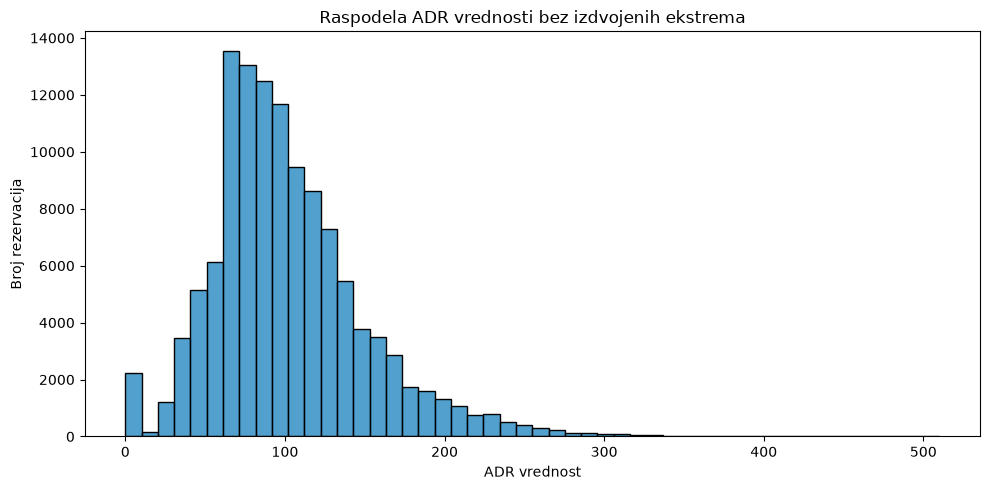

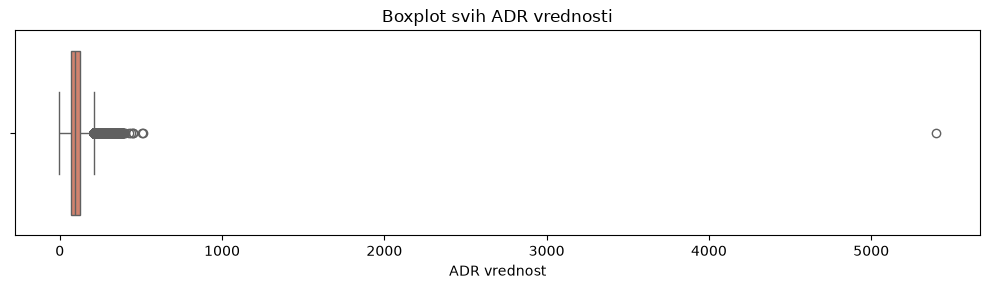

In [18]:
adr_all_values = analysis_df["adr"].dropna()
adr_without_extremes = analysis_df.loc[
    analysis_df["adr"].between(0, 1000),
    "adr"
].dropna()

adr_statistics = pd.DataFrame(
    {
        "Broj zapisa": [adr_all_values.count(), adr_without_extremes.count()],
        "Prosečna vrednost": [adr_all_values.mean(), adr_without_extremes.mean()],
        "Medijana": [adr_all_values.median(), adr_without_extremes.median()],
        "Standardna devijacija": [adr_all_values.std(), adr_without_extremes.std()],
        "Minimum": [adr_all_values.min(), adr_without_extremes.min()],
        "Maksimum": [adr_all_values.max(), adr_without_extremes.max()]
    },
    index=["Svi zapisi", "Bez izdvojenih ADR vrednosti"]
)

display(adr_statistics.round(2))

plt.figure(figsize=(10, 5))
sb.histplot(adr_without_extremes, bins=50, color="#1781BE")
plt.title("Raspodela ADR vrednosti bez izdvojenih ekstrema")
plt.xlabel("ADR vrednost")
plt.ylabel("Broj rezervacija")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
sb.boxplot(x=adr_all_values, color="#E07A5F")
plt.title("Boxplot svih ADR vrednosti")
plt.xlabel("ADR vrednost")
plt.tight_layout()
plt.show()

Nakon privremenog izdvajanja dve ADR vrednosti prosek se smanjuje sa 101,83 na 101,79, dok medijana ostaje 94,58. Dve vrednosti zato ne menjaju vidljivo prosek, ali povećavaju standardnu devijaciju i znatno proširuju raspon, što se jasno uočava na boxplot-u. O tome da li će ostati u skupu odlučiće se u delu čišćenja podataka.

### 7.2. Analiza rezervacija bez evidentiranih gostiju

Rezervacije bez evidentiranih gostiju analiziraju se prema statusu, broju noćenja, ADR vrednosti i informaciji o otkazivanju. Primeri redova se ne prikazuju ponovo jer su već dati u prethodnom delu.

In [19]:
zero_guest_rows = analysis_df[analysis_df["total_guests"] == 0]

zero_guest_status_summary = (
    zero_guest_rows["reservation_status"]
    .value_counts(dropna=False)
    .rename_axis("Status rezervacije")
    .reset_index(name="Broj redova")
)
zero_guest_status_summary["Procenat rezervacija bez gostiju"] = (
    zero_guest_status_summary["Broj redova"] / len(zero_guest_rows) * 100
).round(3)

zero_guest_overview = pd.DataFrame({
    "Pokazatelj": [
        "Ukupan broj rezervacija bez gostiju",
        "Rezervacije bez noćenja",
        "Rezervacije sa najmanje jednim noćenjem",
        "Rezervacije sa ADR jednakim nuli",
        "Rezervacije sa pozitivnim ADR-om",
        "Otkazane rezervacije prema is_canceled"
    ],
    "Broj redova": [
        len(zero_guest_rows),
        (zero_guest_rows["total_stay"] == 0).sum(),
        (zero_guest_rows["total_stay"] > 0).sum(),
        (zero_guest_rows["adr"] == 0).sum(),
        (zero_guest_rows["adr"] > 0).sum(),
        (zero_guest_rows["is_canceled"] == 1).sum()
    ]
})

display(zero_guest_status_summary)
display(zero_guest_overview)

,Status rezervacije,Broj redova,Procenat rezervacija bez gostiju
0,Check-Out,155,86.111
1,Canceled,24,13.333
2,No-Show,1,0.556


,Pokazatelj,Broj redova
0,Ukupan broj rezervacija bez gostiju,180
1,Rezervacije bez noćenja,70
2,Rezervacije sa najmanje jednim noćenjem,110
3,Rezervacije sa ADR jednakim nuli,149
4,Rezervacije sa pozitivnim ADR-om,31
5,Otkazane rezervacije prema is_canceled,25


Rezultati pokazuju da rezervacije bez evidentiranih gostiju imaju različite karakteristike. Među njima postoje realizovane rezervacije, rezervacije sa najmanje jednim noćenjem i rezervacije sa pozitivnim ADR-om. Zbog toga se ovi zapisi ne mogu automatski proglasiti greškom ili ukloniti bez dodatnog razmatranja tokom čišćenja podataka.

### 7.3. Analiza rezervacija bez noćenja

Kod rezervacija bez noćenja provereni su status, otkazivanje, broj gostiju i ADR kako bi se bolje razumelo kakvi se zapisi nalaze u ovoj grupi.

,Status rezervacije,Broj redova,Procenat rezervacija bez noćenja
0,Check-Out,680,95.105
1,Canceled,22,3.077
2,No-Show,13,1.818


,Pokazatelj,Broj redova
0,Ukupan broj rezervacija bez noćenja,715
1,Rezervacije bez evidentiranih gostiju,70
2,Rezervacije sa najmanje jednim gostom,645
3,Rezervacije sa ADR jednakim nuli,715
4,Rezervacije sa pozitivnim ADR-om,0


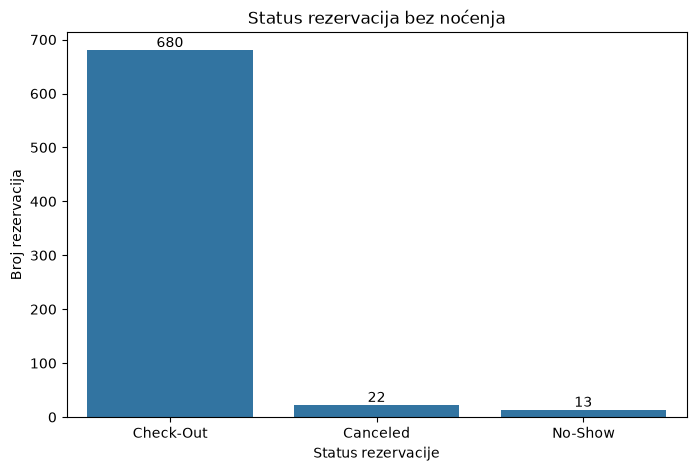

In [20]:
zero_stay_rows = analysis_df[analysis_df["total_stay"] == 0]

zero_stay_status_summary = (
    zero_stay_rows["reservation_status"]
    .value_counts(dropna=False)
    .rename_axis("Status rezervacije")
    .reset_index(name="Broj redova")
)

zero_stay_status_summary["Procenat rezervacija bez noćenja"] = (
    zero_stay_status_summary["Broj redova"] / len(zero_stay_rows) * 100
).round(3)

zero_stay_overview = pd.DataFrame({
    "Pokazatelj": [
        "Ukupan broj rezervacija bez noćenja",
        "Rezervacije bez evidentiranih gostiju",
        "Rezervacije sa najmanje jednim gostom",
        "Rezervacije sa ADR jednakim nuli",
        "Rezervacije sa pozitivnim ADR-om"
    ],
    "Broj redova": [
        len(zero_stay_rows),
        (zero_stay_rows["total_guests"] == 0).sum(),
        (zero_stay_rows["total_guests"] >= 1).sum(),
        (zero_stay_rows["adr"] == 0).sum(),
        (zero_stay_rows["adr"] > 0).sum()
    ]
})

display(zero_stay_status_summary)
display(zero_stay_overview)

plt.figure(figsize=(8, 5))

ax = sb.countplot(
    data=zero_stay_rows,
    x="reservation_status",
    order=zero_stay_rows["reservation_status"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Status rezervacija bez noćenja")
plt.xlabel("Status rezervacije")
plt.ylabel("Broj rezervacija")
plt.show()

Rezultati pokazuju da među rezervacijama bez noćenja preovlađuju zapisi sa statusom Check-Out i da većina ima najmanje jednog evidentiranog gosta. Istovremeno, nijedna od ovih rezervacija nema pozitivan ADR, zbog čega njihovo značenje nije moguće pouzdano utvrditi samo na osnovu dostupnih podataka.

### 7.4. Analiza rezervacija sa neuobičajeno velikim brojem gostiju

Za mali broj rezervacija koje ispunjavaju prethodno definisan kriterijum prikazuju se svi redovi, kao i njihove raspodele prema tržišnom segmentu i statusu rezervacije.

,hotel,is_canceled,adults,children,babies,total_guests,total_stay,adr,market_segment,reservation_status
2173,Resort Hotel,1,55,0.0,0,55.0,2,0.00,Direct,Canceled
1643,Resort Hotel,1,50,0.0,0,50.0,3,0.00,Direct,Canceled
1539,Resort Hotel,1,40,0.0,0,40.0,3,0.00,Direct,Canceled
1962,Resort Hotel,1,27,0.0,0,27.0,4,0.00,Direct,Canceled
1917,Resort Hotel,1,27,0.0,0,27.0,4,0.00,Direct,Canceled
1752,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
1587,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
2003,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
1884,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
2164,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled


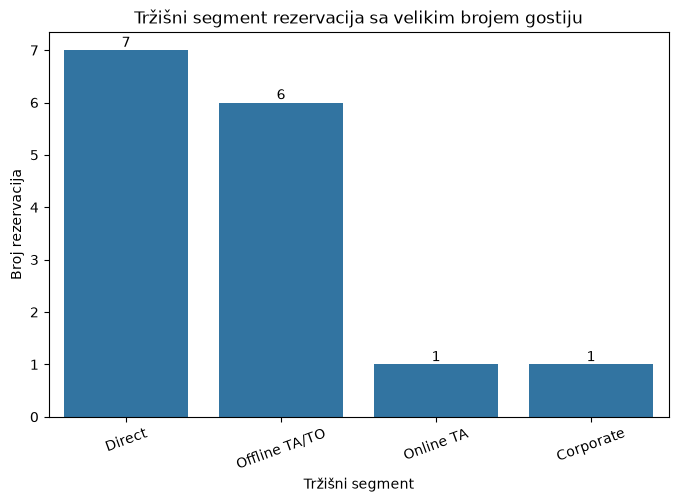

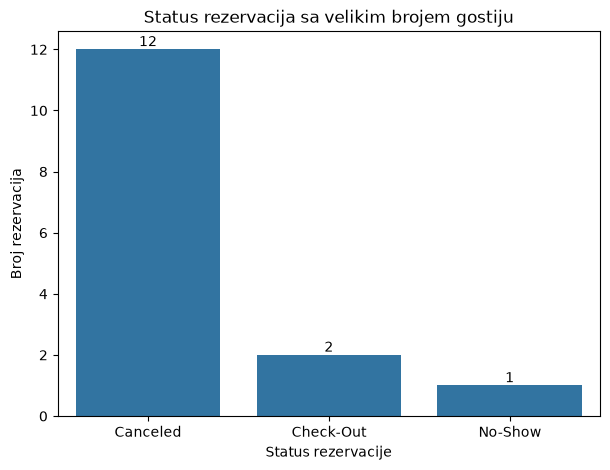

In [21]:
extreme_guest_rows = analysis_df[
    (analysis_df["adults"] > 10)
    | (analysis_df["children"] > 5)
    | (analysis_df["babies"] > 5)
]

extreme_guest_columns = [
    "hotel", "is_canceled", "adults", "children", "babies",
    "total_guests", "total_stay", "adr", "market_segment",
    "reservation_status"
]

display(extreme_guest_rows.sort_values("total_guests", ascending=False)[extreme_guest_columns])

plt.figure(figsize=(8, 5))

market_order = (
    extreme_guest_rows["market_segment"]
    .value_counts()
    .index
)

ax = sb.countplot(
    data=extreme_guest_rows,
    x="market_segment",
    order=market_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Tržišni segment rezervacija sa velikim brojem gostiju")
plt.xlabel("Tržišni segment")
plt.ylabel("Broj rezervacija")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7, 5))

status_order = (
    extreme_guest_rows["reservation_status"]
    .value_counts()
    .index
)

ax = sb.countplot(
    data=extreme_guest_rows,
    x="reservation_status",
    order=status_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Status rezervacija sa velikim brojem gostiju")
plt.xlabel("Status rezervacije")
plt.ylabel("Broj rezervacija")
plt.show()

Među rezervacijama sa neuobičajeno velikim brojem gostiju najzastupljeniji su segmenti Direct i Offline TA/TO, dok je većina ovih rezervacija otkazana. Ipak, postoje i realizovane rezervacije, uključujući one sa većim brojem dece ili beba, što pokazuje da ova grupa nije ujednačena i da obuhvata različite vrste rezervacija.

### 7.5. Veliki lead time i dugo čekanje

U ovom delu analiziraju se rezervacije sa velikim lead_time i dugim čekanjem na listi čekanja. Grupe se porede prema broju rezervacija i procentu otkazivanja kako bi se utvrdilo da li postoji povezanost između ovih karakteristika i učestalosti otkazivanja.

In [22]:
def create_group_comparison(groups):
    rows = []

    for group_name, condition in groups:
        group_rows = analysis_df.loc[condition]

        rows.append({
            "Grupa": group_name,
            "Broj rezervacija": len(group_rows),
            "Procenat ukupnog skupa": round(len(group_rows) / len(analysis_df) * 100, 3),
            "Broj otkazanih rezervacija": group_rows["is_canceled"].sum(),
            "Procenat otkazanih rezervacija": round(group_rows["is_canceled"].mean() * 100, 3)
        })

    return pd.DataFrame(rows)


lead_time_comparison = create_group_comparison([
    (
        "lead_time <= 365",
        analysis_df["lead_time"] <= 365
    ),
    (
        "lead_time > 365",
        analysis_df["lead_time"] > 365
    )
])

waiting_list_comparison = create_group_comparison([
    (
        "days_in_waiting_list <= 100",
        analysis_df["days_in_waiting_list"] <= 100
    ),
    (
        "days_in_waiting_list > 100",
        analysis_df["days_in_waiting_list"] > 100
    )
])

display(lead_time_comparison)
display(waiting_list_comparison)

,Grupa,Broj rezervacija,Procenat ukupnog skupa,Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,lead_time <= 365,116242,97.363,42094,36.212
1,lead_time > 365,3148,2.637,2130,67.662


,Grupa,Broj rezervacija,Procenat ukupnog skupa,Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,days_in_waiting_list <= 100,118643,99.374,43852,36.961
1,days_in_waiting_list > 100,747,0.626,372,49.799


Rezervacije napravljene više od godinu dana unapred imaju znatno veći procenat otkazivanja - 67,662% u odnosu na 36,212% kod rezervacija sa kraćim lead_time. Razlika kod vremena provedenog na listi čekanja je manja, ali je i tu procenat otkazivanja viši kada čekanje traje duže od 100 dana. Rezultati ukazuju da je lead_time izraženije povezan sa otkazivanjem nego dužina čekanja na listi. Ipak, na osnovu ovog poređenja može se govoriti samo o povezanosti, a ne i o uzroku otkazivanja.

### Zaključak detaljnije analize izdvojenih vrednosti

Detaljnija analiza izdvojenih vrednosti pokazala je da izdvojene neuobičajene vrednosti ne treba posmatrati na isti način. Neke od njih mogu se smatrati potencijalno nelogičnim, poput negativnog ADR-a ili rezervacija bez evidentiranih gostiju, dok druge predstavljaju retke, ali moguće slučajeve koji se javljaju u stvarnim podacima. Takođe, uočeno je da rezervacije sa velikim lead_time i dugim čekanjem imaju veći procenat otkazivanja u odnosu na uporedne grupe. U ovoj fazi podaci nisu menjani, već su samo analizirani kako bi se u sledećem poglavlju mogle doneti obrazložene odluke o njihovom zadržavanju, uklanjanju ili drugačijoj obradi.

## 8. Čišćenje podataka

U ovom poglavlju podaci se pripremaju za dalju analizu na osnovu zaključaka iz prethodnih delova. Sve promene primenjuju se na posebnu kopiju, dok originalni DataFrame ostaje nepromenjen.


### 8.1. Plan čišćenja podataka

Na osnovu prethodne analize, čišćenje podataka obuhvata sledeće korake:

- od originalnog `df` kreira se posebna kopija `clean_df`, kako bi izvorni skup ostao nepromenjen;
- obrađuju se nedostajuće vrednosti;
- uklanjaju se direktni identifikatori gostiju koji se neće koristiti u daljoj analizi i modeliranju;
- uklanjaju se kolone koje otkrivaju konačan ishod rezervacije i mogu izazvati curenje podataka;
- posebno se obrađuju dve izdvojene ADR vrednosti;
- uklanjaju se rezervacije bez evidentiranih gostiju;
- zadržavaju se rezervacije bez noćenja, sa neuobičajeno velikim brojem gostiju, velikim `lead_time`, dugim čekanjem i dužim boravkom, jer mogu predstavljati retke, ali moguće slučajeve.

Kolone `name`, `email`, `phone-number` i `credit_card` predstavljaju direktne identifikatore gostiju. Iako prethodno ponašanje gosta može biti povezano sa otkazivanjem, ono je već opisano kolonama `is_repeated_guest`, `previous_cancellations` i `previous_bookings_not_canceled`. Zbog toga se direktni identifikatori uklanjaju kako model ne bi pamtio pojedinačne osobe, već učio obrasce koji se mogu primeniti i na nove goste.

### 8.2. Kreiranje kopije podataka

In [23]:
clean_df = df.copy()

rows_before_cleaning = len(clean_df)
columns_before_cleaning = clean_df.shape[1]

print(f"Broj redova pre čišćenja: {rows_before_cleaning}")
print(f"Broj kolona pre čišćenja: {columns_before_cleaning}")

Broj redova pre čišćenja: 119390
Broj kolona pre čišćenja: 36


Čišćenje se obavlja nad kopijom `clean_df`, tako da originalni skup `df` ostaje nepromenjen i može se koristiti za poređenje sa očišćenim podacima.

### 8.3. Obrada nedostajućih vrednosti

U koloni `children` nedostaju samo četiri vrednosti. One se zamenjuju nulom, jer kolona predstavlja broj dece i treba da sadrži cele brojeve. Korišćenje proseka moglo bi da dovede do decimalne vrednosti, dok je nula smislena pretpostavka za mali broj nedostajućih zapisa. Ipak, nije moguće sa sigurnošću utvrditi da u tim rezervacijama nije bilo dece, već je to odluka doneta radi dalje obrade podataka.

Nedostajuće vrednosti u koloni `country` zamenjuju se oznakom "Unknown". Tu kategoriju mi dodajemo pomoću `fillna("Unknown")`; ona ne predstavlja stvarnu državu, već označava da podatak o državi nije poznat. Postojeće oznake država ostaju nepromenjene.

Kod kolona `agent` i `company`, nedostajuće vrednosti zamenjuju se nulom, koja označava da agent ili kompanija nisu evidentirani. Pošto ove kolone predstavljaju identifikacione brojeve, njihove vrednosti ne treba tumačiti kao obične numeričke veličine.

In [24]:
clean_df["children"] = clean_df["children"].fillna(0).astype(int)

clean_df["country"] = clean_df["country"].fillna("Unknown")

clean_df["agent"] = clean_df["agent"].fillna(0).astype(int)

clean_df["company"] = clean_df["company"].fillna(0).astype(int)

In [25]:
missing_after_filling = (
    clean_df.isna()
    .sum()
    .sort_values(ascending=False)
)

remaining_missing = missing_after_filling[missing_after_filling > 0]

if remaining_missing.empty:
    print("Nakon obrade nema nedostajućih vrednosti.")
else:
    display(remaining_missing.to_frame("Broj nedostajućih vrednosti"))

Nakon obrade nema nedostajućih vrednosti.


### 8.4. Obrada izdvojenih ADR vrednosti

Prethodnom analizom pronađena je jedna negativna i jedna izrazito visoka ADR vrednost. Oba zapisa čine zanemarljiv deo skupa, pa se za dalju analizu zadržavaju rezervacije čiji je ADR u intervalu od 0 do 1000. Nakon izdvajanja vrednosti 5400, najveći preostali ADR iznosi 510. Zbog toga prag od 1000 izdvaja samo izrazito visoku vrednost, bez uklanjanja ostalih rezervacija. Ne može se tvrditi da su izdvojene vrednosti sigurno posledica greške; uklanjaju se zbog nelogične ili izrazito neuobičajene vrednosti u odnosu na ostatak raspodele.

In [26]:
invalid_adr_mask = ~clean_df["adr"].between(0, 1000)

removed_adr_rows = invalid_adr_mask.sum()

clean_df = clean_df.loc[~invalid_adr_mask].copy()

print("Broj uklonjenih redova zbog izdvojenih ADR vrednosti:", removed_adr_rows)

Broj uklonjenih redova zbog izdvojenih ADR vrednosti: 2


### 8.5. Rezervacije bez evidentiranih gostiju

Rezervacije kod kojih su `adults`, `children` i `babies` jednaki nuli nemaju evidentiranog nijednog gosta. Prethodna analiza pokazala je da ova grupa sadrži različite statuse i karakteristike, ali podatak o sastavu gostiju u tim redovima nije potpun ili nije dovoljno pouzdan za dalju analizu. Zbog toga se ti redovi uklanjaju iz očišćenog skupa, dok originalni podaci ostaju sačuvani u `df`.

In [27]:
total_guests = clean_df["adults"] + clean_df["children"] + clean_df["babies"]

zero_guests_mask = total_guests == 0

removed_zero_guest_rows = zero_guests_mask.sum()

clean_df = clean_df.loc[~zero_guests_mask].copy()

print("Broj uklonjenih rezervacija bez evidentiranih gostiju:", removed_zero_guest_rows)

Broj uklonjenih rezervacija bez evidentiranih gostiju: 180


### 8.6. Uklanjanje nekorisnih kolona i sprečavanje curenja podataka

Kolone `name`, `email`, `phone-number` i `credit_card` predstavljaju direktne identifikatore gostiju i zato se neće koristiti za predviđanje otkazivanja. Informacije o prethodnom ponašanju gosta već su opisane kolonama `is_repeated_guest`, `previous_cancellations` i `previous_bookings_not_canceled`, koje ostaju u skupu. Na taj način kasniji model neće pamtiti identitet konkretne osobe, već će koristiti podatke o njenoj istoriji rezervacija.

Kolone `reservation_status` i `reservation_status_date` sadrže informacije koje su poznate tek nakon ishoda rezervacije. Njihovo korišćenje omogućilo bi modelu da posredno vidi odgovor koji treba da predvidi, što predstavlja curenje podataka. Prethodna analiza ovih kolona ostaje sačuvana u `df` i `analysis_df`, ali se one uklanjaju iz `clean_df`.


In [28]:
columns_to_remove = [
    "name",
    "email",
    "phone-number",
    "credit_card",
    "reservation_status",
    "reservation_status_date"
]

existing_columns_to_remove = [
    column
    for column in columns_to_remove
    if column in clean_df.columns
]

clean_df = clean_df.drop(columns=existing_columns_to_remove)

print("Uklonjene kolone:")
print(existing_columns_to_remove)

Uklonjene kolone:
['name', 'email', 'phone-number', 'credit_card', 'reservation_status', 'reservation_status_date']


### 8.7. Vrednosti koje ostaju u skupu

Rezervacije bez noćenja, sa većim brojem gostiju, dužim boravkom, velikim `lead_time`, dugim čekanjem na listi, većim brojem prethodnih rezervacija ili otkazivanja i većim brojem promena rezervacije zadržavaju se u skupu. Iako se pojavljuju retko, predstavljaju moguće slučajeve i mogu ukazati na obrasce relevantne za dalju analizu. Njihov stvarni doprinos predviđanju biće proveren tokom modeliranja.

### 8.8. Pregled izvršenih promena

In [29]:
rows_after_cleaning = len(clean_df)
columns_after_cleaning = clean_df.shape[1]

cleaning_summary = pd.DataFrame({
    "Promena": [
        "Izdvojene ADR vrednosti",
        "Rezervacije bez evidentiranih gostiju",
        "Ukupno uklonjeni redovi",
        "Uklonjene kolone"
    ],
    "Broj": [
        removed_adr_rows,
        removed_zero_guest_rows,
        rows_before_cleaning - rows_after_cleaning,
        columns_before_cleaning - columns_after_cleaning
    ]
})

display(cleaning_summary)

print(f"Dimenzije pre čišćenja: {df.shape}")
print(f"Dimenzije posle čišćenja: {clean_df.shape}")

,Promena,Broj
0,Izdvojene ADR vrednosti,2
1,Rezervacije bez evidentiranih gostiju,180
2,Ukupno uklonjeni redovi,182
3,Uklonjene kolone,6


Dimenzije pre čišćenja: (119390, 36)
Dimenzije posle čišćenja: (119208, 30)


In [30]:
final_validation = pd.Series({
    "Nedostajuće vrednosti": int(clean_df.isna().sum().sum()),
    "Negativne ADR vrednosti": int((clean_df["adr"] < 0).sum()),
    "ADR vrednosti veće od 1000": int((clean_df["adr"] > 1000).sum()),
    "Rezervacije bez evidentiranih gostiju": 
        int((clean_df["adults"] + clean_df["children"] + clean_df["babies"] == 0).sum())
})

display(final_validation.to_frame("Broj preostalih zapisa"))

,Broj preostalih zapisa
Nedostajuće vrednosti,0
Negativne ADR vrednosti,0
ADR vrednosti veće od 1000,0
Rezervacije bez evidentiranih gostiju,0


### 8.9. Provera raspodele ciljne promenljive

Posle čišćenja proverava se odnos otkazanih i neotkazanih rezervacija kako bi se utvrdilo da li je uklanjanje malog broja zapisa značajno promenilo raspodelu ciljne promenljive.

In [31]:
target_distribution_before = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_distribution_after = (
    clean_df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_distribution_comparison = pd.DataFrame({
    "Pre čišćenja (%)": target_distribution_before,
    "Posle čišćenja (%)": target_distribution_after
}).round(3)

target_distribution_comparison.index = [
    "Nije otkazana",
    "Otkazana"
]

display(target_distribution_comparison)

,Pre čišćenja (%),Posle čišćenja (%)
Nije otkazana,62.958,62.924
Otkazana,37.042,37.076


### 8.10. Zaključak čišćenja podataka

Tokom čišćenja obrađene su nedostajuće vrednosti, uklonjeni su direktni identifikatori gostiju i kolone koje bi mogle izazvati curenje podataka. Uklonjene su dve izdvojene ADR vrednosti i rezervacije bez evidentiranih gostiju, dok su retke, ali moguće vrednosti, poput velikog `lead_time`, dugog čekanja, dužih boravaka i većeg broja gostiju, zadržane u skupu.

Ukupno su uklonjena 182 reda i šest kolona, što predstavlja mali deo početnog skupa. Odnos otkazanih i neotkazanih rezervacija ostao je gotovo nepromenjen, pa čišćenje nije značajno uticalo na raspodelu ciljne promenljive. Originalni DataFrame `df` ostao je nepromenjen, dok će se očišćeni skup `clean_df` koristiti u nastavku analize.

## 9. Eksplorativna analiza podataka

Nakon čišćenja podataka sledi eksplorativna analiza očišćenog skupa. Cilj ovog poglavlja je da se ispita raspodela ciljne promenljive `is_canceled` i njen odnos sa odabranim karakteristikama rezervacija.

### 9.1. Priprema podataka za eksplorativnu analizu

Za eksplorativnu analizu kreira se posebna kopija `eda_df`. Na taj način `clean_df` ostaje nepromenjen, dok se u `eda_df` po potrebi dodaju pomoćne kolone koje olakšavaju analizu.

In [32]:
eda_df = clean_df.copy()

eda_df["status_otkazivanja"] = eda_df["is_canceled"].map({
    0: "Nije otkazana",
    1: "Otkazana"
})

print(f"Dimenzije skupa za EDA: {eda_df.shape}")

def create_cancellation_summary(data, column):
    summary = (
        data.groupby(column, dropna=False)["is_canceled"]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            "count": "Broj rezervacija",
            "sum": "Broj otkazanih rezervacija",
            "mean": "Procenat otkazanih rezervacija"
        })
    )

    summary["Udeo u ukupnom skupu (%)"] = (summary["Broj rezervacija"] / len(data) * 100).round(2)
    summary["Procenat otkazanih rezervacija"] = (summary["Procenat otkazanih rezervacija"] * 100).round(2)

    return summary[[column, "Broj rezervacija", "Udeo u ukupnom skupu (%)",
                    "Broj otkazanih rezervacija", "Procenat otkazanih rezervacija"]]

Dimenzije skupa za EDA: (119208, 31)


Pomoćna funkcija za svaku grupu računa ukupan broj rezervacija, njen udeo u celom skupu, broj otkazanih rezervacija i procenat otkazivanja unutar te grupe.

### 9.2. Raspodela ciljne promenljive

Najpre se analizira odnos otkazanih i neotkazanih rezervacija, kako bi se stekao uvid u raspodelu ciljne promenljive.

,Broj rezervacija,Procenat rezervacija
status_otkazivanja,,
Nije otkazana,75010,62.92
Otkazana,44198,37.08


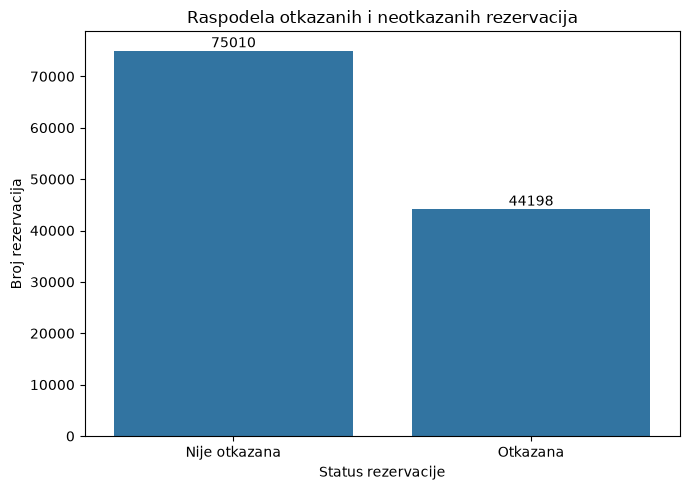

In [33]:
status_order = [
    "Nije otkazana",
    "Otkazana"
]

target_counts = (
    eda_df["status_otkazivanja"]
    .value_counts()
    .reindex(status_order)
)

target_percentages = (
    eda_df["status_otkazivanja"]
    .value_counts(normalize=True)
    .reindex(status_order) * 100
)

target_summary = pd.DataFrame({
    "Broj rezervacija": target_counts,
    "Procenat rezervacija": target_percentages
}).round(2)

display(target_summary)

plt.figure(figsize=(7, 5))

ax = sb.countplot(
    data=eda_df,
    x="status_otkazivanja",
    order=status_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Raspodela otkazanih i neotkazanih rezervacija")
plt.xlabel("Status rezervacije")
plt.ylabel("Broj rezervacija")
plt.tight_layout()
plt.show()

U skupu preovlađuju neotkazane rezervacije, kojih ima 75.010 (62,92%), dok je otkazanih rezervacija 44.198 (37,08%). Obe grupe zastupljene su u velikom broju, što omogućava njihovo dalje poređenje.

### 9.3. Tip hotela i otkazivanje

Proverava se da li se procenat otkazivanja razlikuje između gradskog i resort hotela.

,hotel,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,City Hotel,79162,66.41,33078,41.79
1,Resort Hotel,40046,33.59,11120,27.77


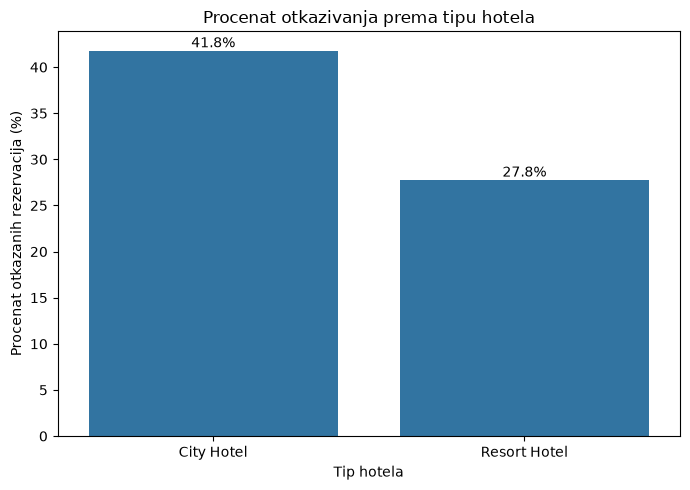

In [34]:
hotel_summary = create_cancellation_summary(eda_df, "hotel")

display(hotel_summary)

plt.figure(figsize=(7, 5))

ax = sb.barplot(
    data=hotel_summary,
    x="hotel",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema tipu hotela")
plt.xlabel("Tip hotela")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

U posmatranom skupu uočava se viši procenat otkazivanja kod City Hotel-a (41,79%) nego kod Resort Hotel-a (27,77%). Gradski hoteli čine i veći deo skupa, sa 79.162 rezervacije, dok resort hoteli imaju 40.046 rezervacija.

### 9.4. Lead time i otkazivanje

`lead_time` predstavlja broj dana između rezervisanja i planiranog dolaska. Ovde se ispituje njegova povezanost sa statusom otkazivanja. Radi preglednijeg prikaza raspodele, izdvojene vrednosti nisu prikazane na boxplot-u, ali su zadržane u podacima.

,Broj_rezervacija,Prosek,Medijana,Minimum,Maksimum
status_otkazivanja,,,,,
Nije otkazana,75010,80.08,45.0,0,737
Otkazana,44198,144.89,113.0,0,629


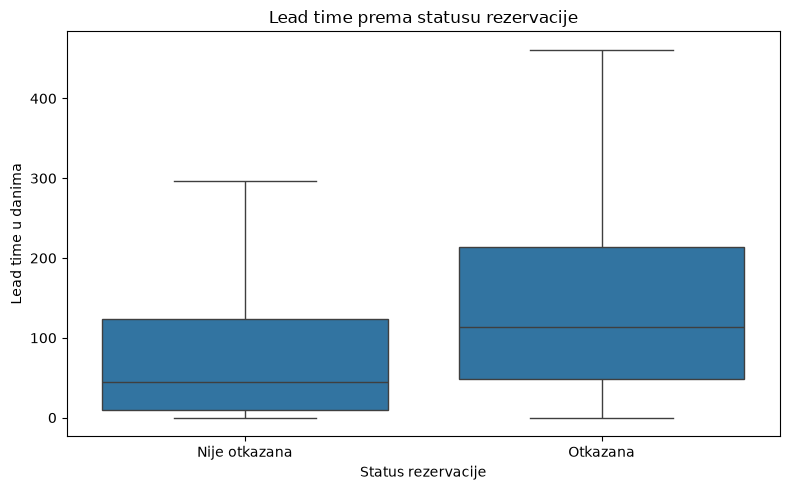

In [35]:
lead_time_statistics = (
    eda_df.groupby("status_otkazivanja")["lead_time"]
    .agg(
        Broj_rezervacija="count",
        Prosek="mean",
        Medijana="median",
        Minimum="min",
        Maksimum="max"
    ).round(2)
)

display(lead_time_statistics)


plt.figure(figsize=(8, 5))

sb.boxplot(
    data=eda_df,
    x="status_otkazivanja",
    y="lead_time",
    showfliers=False
)

plt.title("Lead time prema statusu rezervacije")
plt.xlabel("Status rezervacije")
plt.ylabel("Lead time u danima")
plt.tight_layout()
plt.show()

Otkazane rezervacije imaju veći `lead_time` od neotkazanih rezervacija. Medijana iznosi 113 dana kod otkazanih, dok je kod neotkazanih 45 dana. Boxplot pokazuje da su vrednosti `lead_time` kod otkazanih rezervacija raspoređene u širem opsegu, što ukazuje na veću varijabilnost u odnosu na neotkazane rezervacije.

Pored pojedinačnih vrednosti, `lead_time` je podeljen u nekoliko intervala kako bi se lakše uočilo kako se procenat otkazivanja menja sa dužinom perioda između rezervisanja i planiranog dolaska.

,lead_time_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,0-30 dana,38580,32.36,7168,18.58
1,31-90 dana,29528,24.77,11140,37.73
2,91-180 dana,26420,22.16,11819,44.74
3,181-365 dana,21533,18.06,11942,55.46
4,Više od 365 dana,3147,2.64,2129,67.65


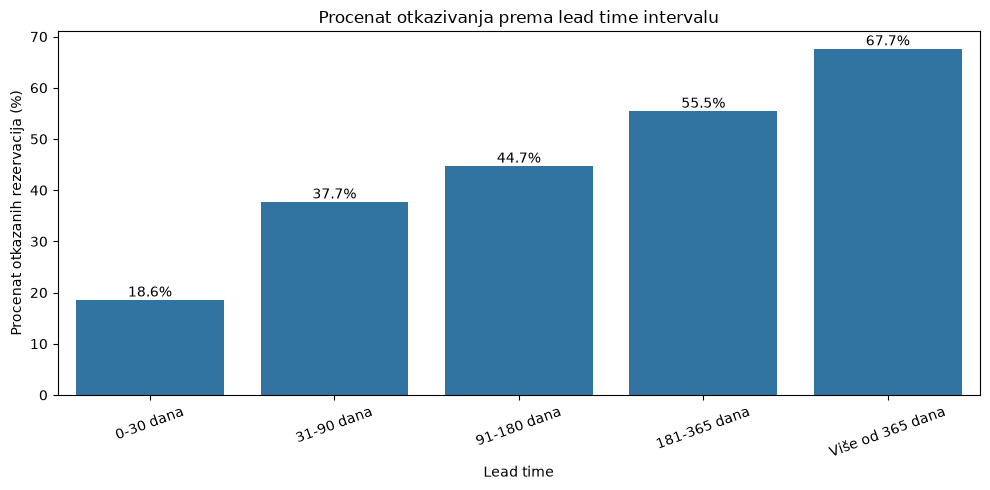

In [36]:
lead_time_bins = [
    -1,
    30,
    90,
    180,
    365,
    np.inf
]

lead_time_labels = [
    "0-30 dana",
    "31-90 dana",
    "91-180 dana",
    "181-365 dana",
    "Više od 365 dana"
]

eda_df["lead_time_group"] = pd.cut(
    eda_df["lead_time"],
    bins=lead_time_bins,
    labels=lead_time_labels
)

lead_time_group_summary = create_cancellation_summary(
    eda_df,
    "lead_time_group"
)

display(lead_time_group_summary)

plt.figure(figsize=(10, 5))

ax = sb.barplot(
    data=lead_time_group_summary,
    x="lead_time_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.title("Procenat otkazivanja prema lead time intervalu")
plt.xlabel("Lead time")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Rezultati pokazuju da se sa povećanjem `lead_time` povećava i procenat otkazanih rezervacija. Najmanji procenat otkazivanja zabeležen je kod rezervacija sa `lead_time` do 30 dana (18,58%), dok najveći procenat ima grupa sa više od 365 dana (67,65%). Iako je poslednja grupa najmanje zastupljena, u njoj se uočava najveći udeo otkazanih rezervacija.

### 9.5. Tip depozita i otkazivanje

Tip depozita može biti povezan sa odlukom gosta da odustane od rezervacije, pa se porede zastupljenost i procenat otkazivanja za svaku kategoriju.
- `No Deposit` – Rezervacija je napravljena bez zahteva za uplatu depozita prilikom rezervisanja.
- `Non Refund` – Rezervacija je povezana sa uslovima koji ne predviđaju povraćaj uplaćenog depozita u slučaju otkazivanja.
- `Refundable` – Rezervacija je napravljena uz depozit koji može biti vraćen pod određenim uslovima.

,deposit_type,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Non Refund,14586,12.24,14493,99.36
1,No Deposit,104460,87.63,29669,28.40
2,Refundable,162,0.14,36,22.22


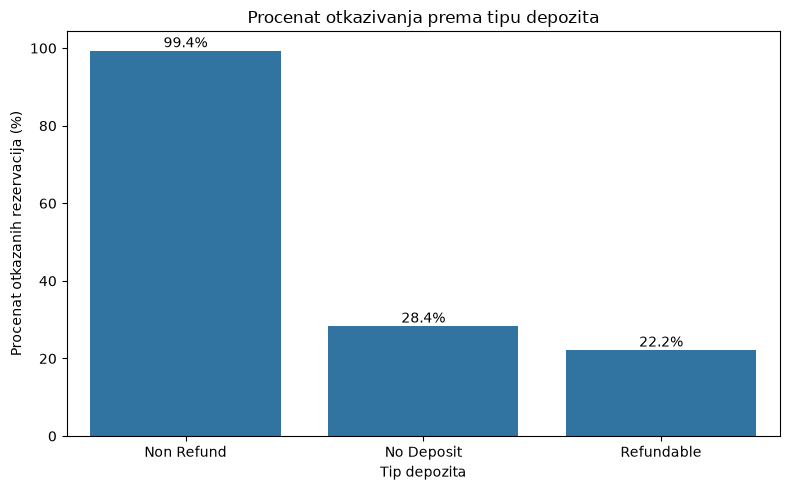

In [37]:
deposit_summary = (
    create_cancellation_summary(
        eda_df,
        "deposit_type"
    )
    .sort_values(
        "Procenat otkazanih rezervacija",
        ascending=False
    ).reset_index(drop=True)
)

display(deposit_summary)

plt.figure(figsize=(8, 5))

ax = sb.barplot(
    data=deposit_summary,
    x="deposit_type",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema tipu depozita")
plt.xlabel("Tip depozita")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Rezervacije sa depozitom `Non Refund` izdvajaju se po veoma visokom procentu otkazivanja od 99,36%. Ovaj rezultat deluje neuobičajeno, ali njegov razlog nije moguće utvrditi samo na osnovu dostupnih podataka. Kod rezervacija bez depozita procenat otkazivanja iznosi 28,40%, dok kategorija `Refundable` ima 22,22% otkazivanja, ali obuhvata svega 162 rezervacije. Rezultati pokazuju izraženu povezanost između tipa depozita i statusa otkazivanja, bez pretpostavljanja razloga zbog kojeg se ovakav obrazac pojavljuje.

### 9.6. Tržišni segment i kanal rezervacije

Kolona `market_segment` opisuje tržišni segment rezervacije, dok `distribution_channel` označava kanal preko kojeg je rezervacija stigla. Cilj analize je da se utvrdi da li se procenat otkazivanja razlikuje između različitih segmenata i kanala distribucije.

Kolona `market_segment` označava tržišni segment iz kojeg potiče rezervacija, odnosno način na koji je gost ili grupa gostiju došla do hotela (na primer preko internet agencije, turističke agencije ili direktno). U nastavku se ispituje kako se procenat otkazivanja razlikuje između pojedinih tržišnih segmenata.

,market_segment,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Undefined,2,0.00,2,100.00
1,Groups,19790,16.60,12094,61.11
2,Online TA,56408,47.32,20735,36.76
3,Offline TA/TO,24181,20.28,8301,34.33
4,Aviation,235,0.20,52,22.13
5,Corporate,5282,4.43,991,18.76
6,Direct,12582,10.55,1934,15.37
7,Complementary,728,0.61,89,12.23


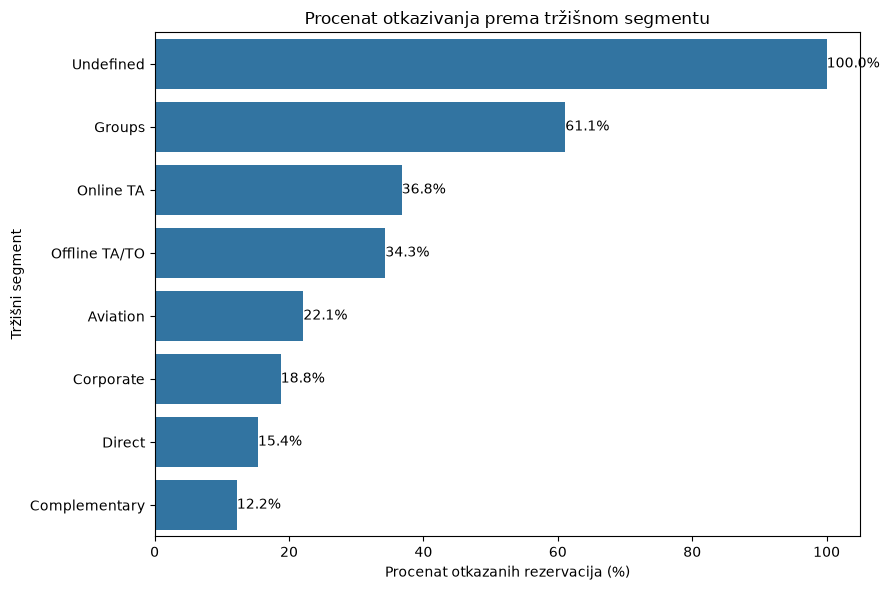

In [38]:
market_segment_summary = (
    create_cancellation_summary(
        eda_df,
        "market_segment"
    )
    .sort_values(
        "Procenat otkazanih rezervacija",
        ascending=False
    )
    .reset_index(drop=True)
)

display(market_segment_summary)


plt.figure(figsize=(9, 6))

ax = sb.barplot(
    data=market_segment_summary,
    y="market_segment",
    x="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema tržišnom segmentu")
plt.xlabel("Procenat otkazanih rezervacija (%)")
plt.ylabel("Tržišni segment")
plt.tight_layout()
plt.show()

Najveći procenat otkazivanja ima kategorija `Undefined`, ali ona sadrži svega dve rezervacije i zbog toga nije reprezentativna. Među zastupljenijim segmentima najveći procenat otkazivanja ima `Groups` (61,11%), zatim `Online TA` (36,76%) i `Offline TA/TO` (34,33%). Najniži procenat otkazivanja zabeležen je kod segmenata `Direct` (15,37%) i `Complementary` (12,23%). Rezultati pokazuju da se procenat otkazivanja razlikuje između tržišnih segmenata.

### Kratak opis kategorija

* **Direct** – rezervacija je izvršena direktno kod hotela.
* **Online TA** – rezervacija je stigla preko internet turističke agencije (npr. Booking.com, Expedia).
* **Offline TA/TO** – rezervacija je stigla preko klasične turističke agencije ili turoperatora.
* **Corporate** – rezervacija je povezana sa poslovnim klijentima ili kompanijama.
* **Groups** – grupne rezervacije.
* **Complementary** – besplatne ili promotivne rezervacije koje hotel odobrava bez naplate.
* **Aviation** – rezervacije povezane sa avio-kompanijama ili njihovim posadama.
* **Undefined** – segment nije definisan u podacima.

Kolona `distribution_channel` opisuje kanal preko kojeg je rezervacija stigla do hotela. Cilj analize je da se utvrdi da li se procenat otkazivanja razlikuje između različitih kanala distribucije. Jedina nova kategorija u odnosu na `market_segment` je **GDS** (Global Distribution System), odnosno globalni distribucioni sistem koji koriste turističke agencije i avio-kompanije za rezervacije.

,distribution_channel,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Undefined,5,0.00,4,80.00
1,TA/TO,97749,82.00,40135,41.06
2,Corporate,6651,5.58,1467,22.06
3,GDS,193,0.16,37,19.17
4,Direct,14610,12.26,2555,17.49


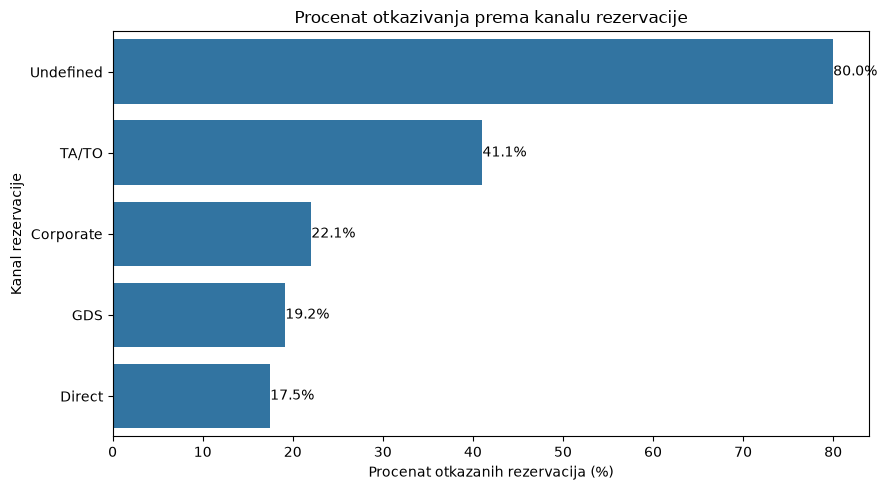

In [39]:
distribution_channel_summary = (
    create_cancellation_summary(
        eda_df,
        "distribution_channel"
    )
    .sort_values(
        "Procenat otkazanih rezervacija",
        ascending=False
    )
    .reset_index(drop=True)
)

display(distribution_channel_summary)


plt.figure(figsize=(9, 5))

ax = sb.barplot(
    data=distribution_channel_summary,
    y="distribution_channel",
    x="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema kanalu rezervacije")
plt.xlabel("Procenat otkazanih rezervacija (%)")
plt.ylabel("Kanal rezervacije")
plt.tight_layout()
plt.show()

Zbog veoma malog broja rezervacija kategorija `Undefined` nije pogodna za izvođenje zaključaka. Kod ostalih kanala distribucije najveći procenat otkazivanja ima `TA/TO`, dok `Direct` ima najmanji. Rezultati pokazuju da se procenat otkazivanja razlikuje između kanala preko kojih su rezervacije stigle do hotela.

### 9.7. Prethodno ponašanje gosta

U ovom delu analizira se da li se ponašanje gostiju iz prethodnih rezervacija razlikuje između otkazanih i neotkazanih rezervacija. Za to se koriste podaci o tome da li je gost već ranije boravio u hotelu, koliko je prethodnih rezervacija otkazao i koliko ih je uspešno realizovao. Direktni identifikatori gostiju se ne koriste.

,repeated_guest_label,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Novi gost,115454,96.85,43648,37.81
1,Ponovljeni gost,3754,3.15,550,14.65


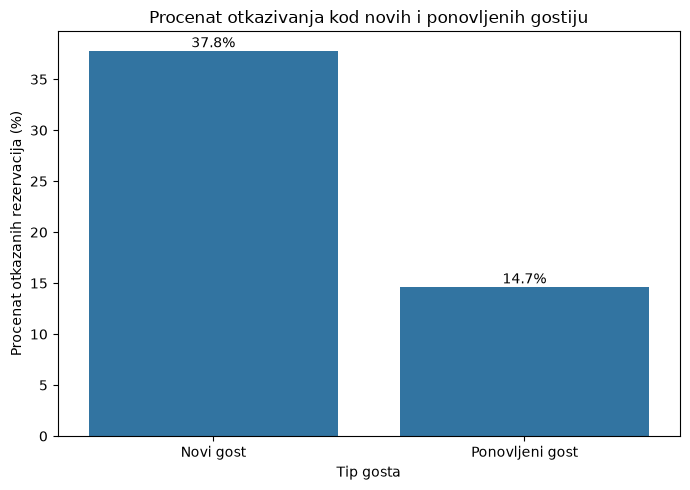

In [40]:
eda_df["repeated_guest_label"] = (
    eda_df["is_repeated_guest"]
    .map({
        0: "Novi gost",
        1: "Ponovljeni gost"
    })
)

repeated_guest_summary = create_cancellation_summary(
    eda_df,
    "repeated_guest_label"
)

display(repeated_guest_summary)


plt.figure(figsize=(7, 5))

ax = sb.barplot(
    data=repeated_guest_summary,
    x="repeated_guest_label",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja kod novih i ponovljenih gostiju")
plt.xlabel("Tip gosta")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Većinu rezervacija čine novi gosti (96,85%), dok ponovljeni gosti učestvuju sa 3,15%. Kod ponovljenih gostiju procenat otkazivanja iznosi 14,65%, što je znatno manje u odnosu na 37,81% kod novih gostiju. Rezultati pokazuju da se procenat otkazivanja razlikuje u zavisnosti od toga da li je gost ranije već boravio u hotelu.

,previous_cancellations_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Bez prethodnih otkazivanja,112729,94.56,38258,33.94
1,Jedno prethodno otkazivanje,6048,5.07,5712,94.44
2,Dva ili više,431,0.36,228,52.90


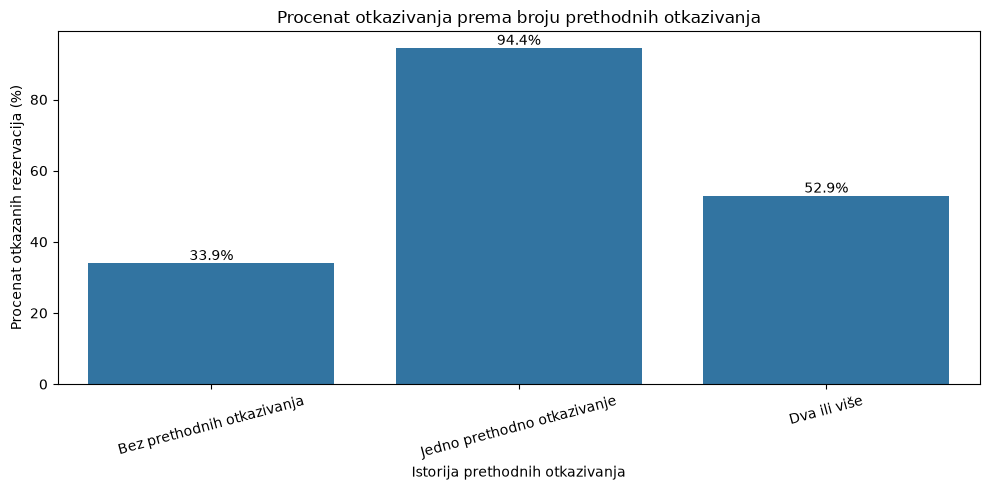

,previous_completed_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,0,115596,96.97,43998,38.06
1,1,1538,1.29,79,5.14
2,2-5,1322,1.11,72,5.45
3,6 ili više,752,0.63,49,6.52


In [41]:
previous_cancellations_bins = [
    -1,
    0,
    1,
    np.inf
]

previous_cancellations_labels = [
    "Bez prethodnih otkazivanja",
    "Jedno prethodno otkazivanje",
    "Dva ili više"
]

eda_df["previous_cancellations_group"] = pd.cut(
    eda_df["previous_cancellations"],
    bins=previous_cancellations_bins,
    labels=previous_cancellations_labels
)

previous_cancellations_summary = create_cancellation_summary(
    eda_df,
    "previous_cancellations_group"
)

display(previous_cancellations_summary)


plt.figure(figsize=(10, 5))

ax = sb.barplot(
    data=previous_cancellations_summary,
    x="previous_cancellations_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema broju prethodnih otkazivanja")
plt.xlabel("Istorija prethodnih otkazivanja")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

previous_completed_bins = [
    -1,
    0,
    1,
    5,
    np.inf
]

previous_completed_labels = [
    "0",
    "1",
    "2-5",
    "6 ili više"
]

eda_df["previous_completed_group"] = pd.cut(
    eda_df["previous_bookings_not_canceled"],
    bins=previous_completed_bins,
    labels=previous_completed_labels
)

previous_completed_summary = create_cancellation_summary(
    eda_df,
    "previous_completed_group"
)

display(previous_completed_summary)

Većina rezervacija (94,56%) nema prethodnih otkazivanja, a u toj grupi procenat otkazivanja iznosi 33,94%. Kod gostiju sa jednim prethodnim otkazivanjem procenat otkazivanja raste na 94,44%. Grupa sa dva ili više prethodnih otkazivanja obuhvata svega 431 rezervaciju, što je znatno manje u odnosu na ostale grupe. Rezultati pokazuju izraženu razliku u procentu otkazivanja u zavisnosti od istorije prethodnih otkazivanja.

Sličan obrazac uočava se i kod prethodno realizovanih rezervacija. Gosti bez prethodnih uspešno realizovanih rezervacija imaju procenat otkazivanja od 38,06%, dok kod gostiju koji imaju jednu ili više prethodno realizovanih rezervacija taj procenat iznosi između 5,14% i 6,52%. Iako ove grupe obuhvataju mali deo skupa, procenat otkazivanja kod njih je znatno niži nego kod gostiju bez prethodno realizovanih rezervacija.

### 9.8. Posebni zahtevi i promene rezervacije

U ovom delu ispituje se povezanost broja posebnih zahteva i broja promena rezervacije sa otkazivanjem rezervacije.

,total_of_special_requests,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,0,70199,58.89,33533,47.77
1,1,33183,27.84,7316,22.05
2,2,12952,10.87,2866,22.13
3,3,2494,2.09,445,17.84
4,4,340,0.29,36,10.59
5,5,40,0.03,2,5.00


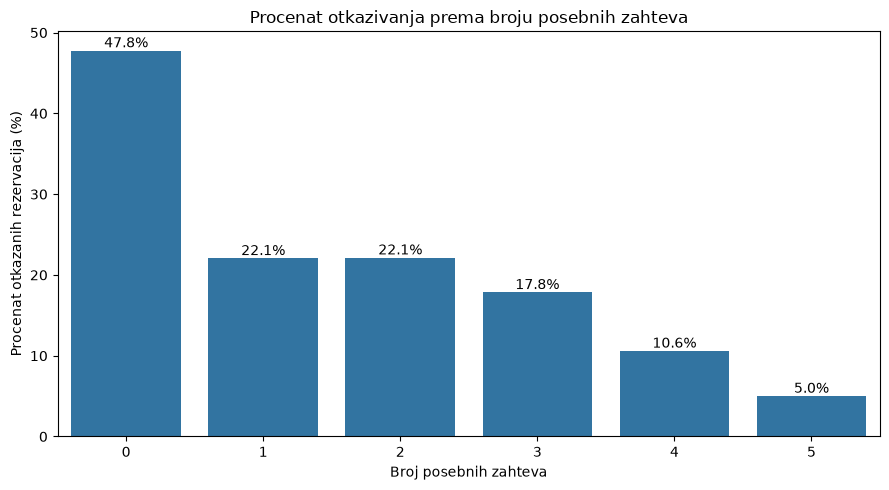

In [42]:
special_requests_summary = create_cancellation_summary(
    eda_df,
    "total_of_special_requests"
)

display(special_requests_summary)

plt.figure(figsize=(9, 5))

ax = sb.barplot(
    data=special_requests_summary,
    x="total_of_special_requests",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema broju posebnih zahteva")
plt.xlabel("Broj posebnih zahteva")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Rezultati pokazuju da se sa povećanjem broja posebnih zahteva smanjuje procenat otkazivanja rezervacija. Dok je kod rezervacija bez posebnih zahteva otkazano 47,77%, kod rezervacija sa tri, četiri i pet zahteva procenat otkazivanja iznosi 17,84%, 10,59% i 5,00%. Poslednje dve grupe sadrže mali broj rezervacija, ali se i pored toga uočava izražen obrazac opadanja procenta otkazivanja sa porastom broja posebnih zahteva.

,booking_changes_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Bez promena,101232,84.92,41369,40.87
1,Jedna promena,12665,10.62,1803,14.24
2,Dve ili više promena,5311,4.46,1026,19.32


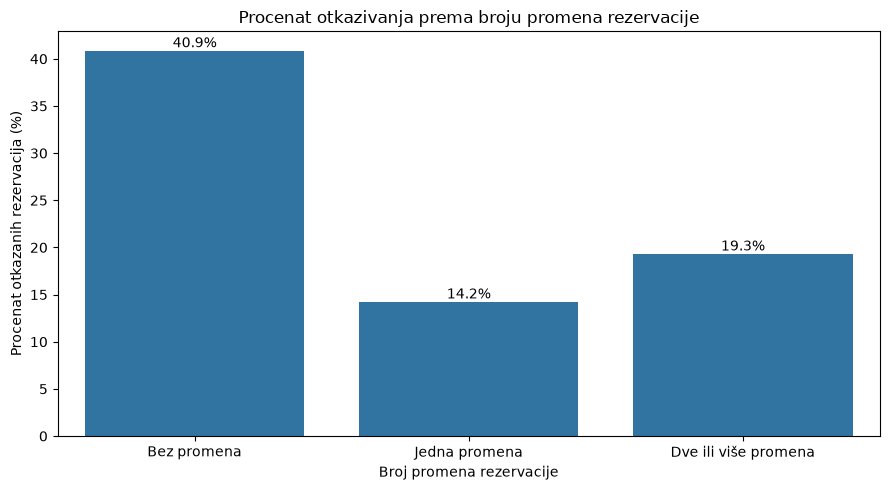

In [43]:
booking_changes_bins = [
    -1,
    0,
    1,
    np.inf
]

booking_changes_labels = [
    "Bez promena",
    "Jedna promena",
    "Dve ili više promena"
]

eda_df["booking_changes_group"] = pd.cut(
    eda_df["booking_changes"],
    bins=booking_changes_bins,
    labels=booking_changes_labels
)

booking_changes_summary = create_cancellation_summary(
    eda_df,
    "booking_changes_group"
)

display(booking_changes_summary)


plt.figure(figsize=(9, 5))

ax = sb.barplot(
    data=booking_changes_summary,
    x="booking_changes_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema broju promena rezervacije")
plt.xlabel("Broj promena rezervacije")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Najveći deo rezervacija (84,92%) nije imao nijednu promenu nakon rezervisanja, a u toj grupi procenat otkazivanja iznosi 40,87%. Kod rezervacija sa jednom promenom procenat otkazivanja opada na 14,24%, dok kod rezervacija sa dve ili više promena iznosi 19,32%. Iako je procenat kod poslednje grupe nešto veći nego kod rezervacija sa jednom promenom, i dalje je znatno niži nego kod rezervacija bez promena. Rezultati pokazuju da su rezervacije kod kojih je izvršena makar jedna promena ređe otkazivane.

### 9.9. ADR i dužina boravka

U ovom delu ispituju se povezanost cene rezervacije (`adr` – Average Daily Rate, odnosno prosečna cena po noćenju) i ukupnog broja noćenja sa otkazivanjem rezervacije. Kolona `total_stay` privremeno se dodaje samo u `eda_df`, dok `clean_df` ostaje nepromenjen. Na boxplot grafikonima izdvojene vrednosti su sakrivene radi preglednijeg prikaza, ali su i dalje deo skupa podataka.

,Broj_rezervacija,Prosek,Medijana,Minimum,Maksimum
status_otkazivanja,,,,,
Nije otkazana,75010,100.17,92.7,0.0,510.0
Otkazana,44198,104.90,96.3,0.0,450.0


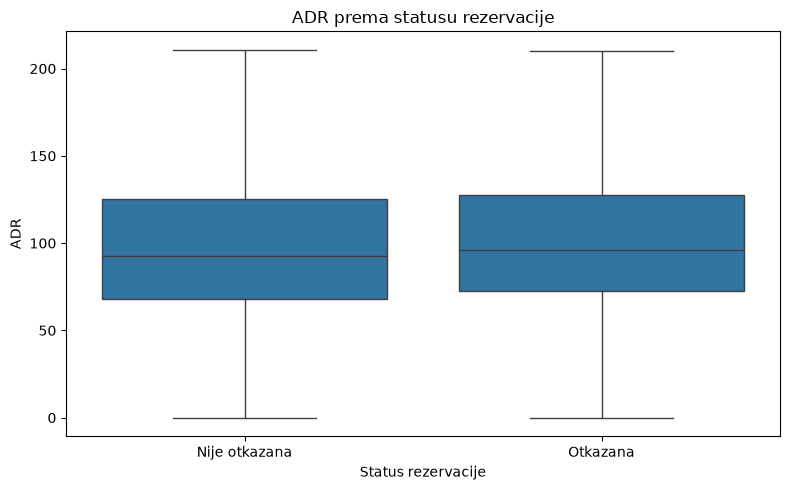

In [44]:
eda_df["total_stay"] = eda_df["stays_in_weekend_nights"] + eda_df["stays_in_week_nights"]

adr_statistics = (
    eda_df.groupby("status_otkazivanja")["adr"]
    .agg(
        Broj_rezervacija="count",
        Prosek="mean",
        Medijana="median",
        Minimum="min",
        Maksimum="max"
    ).round(2)
)

display(adr_statistics)

plt.figure(figsize=(8, 5))

sb.boxplot(
    data=eda_df,
    x="status_otkazivanja",
    y="adr",
    showfliers=False
)

plt.title("ADR prema statusu rezervacije")
plt.xlabel("Status rezervacije")
plt.ylabel("ADR")
plt.tight_layout()
plt.show()

Prosečna i medijalna vrednost ADR-a nešto su veće kod otkazanih rezervacija, ali su razlike male. Boxplot pokazuje da se raspodele u velikoj meri preklapaju, pa se na osnovu same vrednosti ADR-a ne može jasno razlikovati da li će rezervacija biti otkazana.

,total_stay_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Bez noćenja,645,0.54,23,3.57
1,1-3 noćenja,75700,63.50,28778,38.02
2,4-7 noćenja,37638,31.57,13519,35.92
3,8-14 noćenja,4796,4.02,1636,34.11
4,Više od 14 noćenja,429,0.36,242,56.41


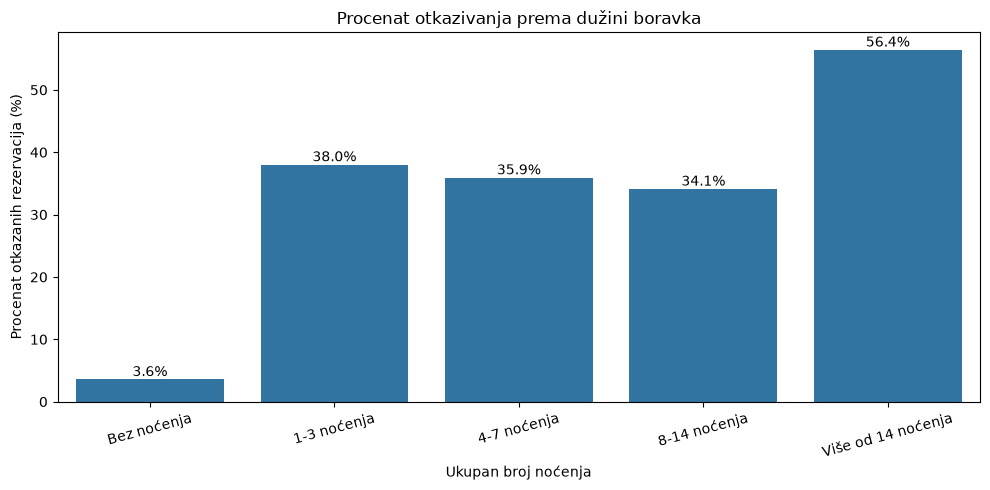

In [45]:
total_stay_bins = [
    -1,
    0,
    3,
    7,
    14,
    np.inf
]

total_stay_labels = [
    "Bez noćenja",
    "1-3 noćenja",
    "4-7 noćenja",
    "8-14 noćenja",
    "Više od 14 noćenja"
]

eda_df["total_stay_group"] = pd.cut(
    eda_df["total_stay"],
    bins=total_stay_bins,
    labels=total_stay_labels
)

total_stay_summary = create_cancellation_summary(
    eda_df,
    "total_stay_group"
)

display(total_stay_summary)

plt.figure(figsize=(10, 5))

ax = sb.barplot(
    data=total_stay_summary,
    x="total_stay_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema dužini boravka")
plt.xlabel("Ukupan broj noćenja")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Najveći deo rezervacija odnosi se na boravke od 1 do 3 noćenja (63,50%) i od 4 do 7 noćenja (31,57%). Kod ovih grupa procenat otkazivanja je sličan i kreće se između 34% i 38%. Rezervacije bez noćenja imaju veoma nizak procenat otkazivanja (3,57%), ali čine svega 0,54% skupa. Najveći procenat otkazivanja zabeležen je kod boravaka dužih od 14 noćenja (56,41%), međutim ova grupa obuhvata samo 429 rezervacija. Rezultati ukazuju da duži boravci mogu biti povezani sa većim procentom otkazivanja, ali se takvi boravci retko javljaju u posmatranom skupu.

### 9.10. Rezervacije prema mesecu i godini dolaska

U ovom delu ispituju se broj rezervacija i procenat otkazivanja prema mesecu i godini planiranog dolaska.

,arrival_date_month,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,January,5921,4.97,1806,30.50
1,February,8052,6.75,2693,33.45
2,March,9766,8.19,3147,32.22
3,April,11078,9.29,4518,40.78
4,May,11780,9.88,4677,39.70
5,June,10929,9.17,4534,41.49
6,July,12644,10.61,4737,37.46
7,August,13861,11.63,5237,37.78
8,September,10500,8.81,4115,39.19
9,October,11147,9.35,4246,38.09


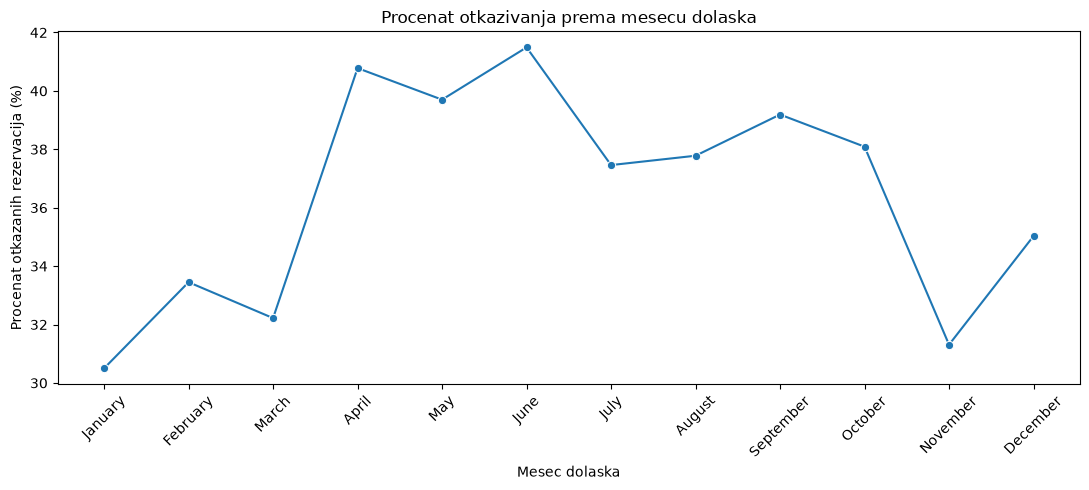

,arrival_date_year,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,2015,21967,18.43,8141,37.06
1,2016,56622,47.50,20323,35.89
2,2017,40619,34.07,15734,38.74


,Godina,Broj obuhvaćenih meseci,Obuhvaćeni meseci
0,2015,6,"July, August, September, October, November, De..."
1,2016,12,"January, February, March, April, May, June, Ju..."
2,2017,8,"January, February, March, April, May, June, Ju..."


In [46]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

month_summary = create_cancellation_summary(
    eda_df,
    "arrival_date_month"
)

month_summary["arrival_date_month"] = pd.Categorical(
    month_summary["arrival_date_month"],
    categories=month_order,
    ordered=True
)

month_summary = (
    month_summary
    .sort_values("arrival_date_month")
    .reset_index(drop=True)
)

display(month_summary)

plt.figure(figsize=(11, 5))

sb.lineplot(
    data=month_summary,
    x="arrival_date_month",
    y="Procenat otkazanih rezervacija",
    marker="o"
)

plt.title("Procenat otkazivanja prema mesecu dolaska")
plt.xlabel("Mesec dolaska")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

year_summary = (
    create_cancellation_summary(
        eda_df,
        "arrival_date_year"
    )
    .sort_values("arrival_date_year")
    .reset_index(drop=True)
)

display(year_summary)

year_month_coverage = (
    eda_df
    .groupby("arrival_date_year")
    .agg(
        broj_meseci=(
            "arrival_date_month",
            "nunique"
        ),
        obuhvaceni_meseci=(
            "arrival_date_month",
            lambda values: ", ".join(
                month
                for month in month_order
                if month in set(values)
            )
        )
    )
    .reset_index()
    .rename(columns={
        "arrival_date_year": "Godina",
        "broj_meseci": "Broj obuhvaćenih meseci",
        "obuhvaceni_meseci": "Obuhvaćeni meseci"
    })
)

display(year_month_coverage)

#### Mesec dolaska

Procenat otkazivanja razlikuje se između meseci. Najniže vrednosti zabeležene su u januaru (30,50%), martu (32,22%) i novembru (31,31%), dok su najveće u aprilu (40,78%) i junu (41,49%). Rezultati pokazuju da procenat otkazivanja nije isti tokom cele godine, već se razlikuje od meseca do meseca.

#### Godina dolaska

Procenat otkazivanja u dostupnim podacima iznosi 37,06% za 2015, 35,89% za 2016. i 38,74% za 2017. godinu. Ove vrednosti su približno slične, ali godine nisu jednako obuhvaćene: podaci za 2015. počinju u julu, 2016. obuhvata svih dvanaest meseci, dok se podaci za 2017. završavaju u avgustu. Zbog toga se poređenje godina prikazuje opisno i na osnovu njega se ne izvodi zaključak o dugoročnom rastu ili padu otkazivanja.

### 9.11. Statistička provera odabranih povezanosti

Grafikoni i tabele iz prethodnog dela pokazuju kako se procenat otkazivanja razlikuje između pojedinih grupa, ali na osnovu njih nije moguće utvrditi da li su uočene razlike statistički značajne ili su mogle nastati slučajno. Zato se u ovom delu primenjuju statistički testovi.

Testovi su primenjeni na nekoliko unapred odabranih promenljivih kod kojih su tokom eksplorativne analize uočene izraženije ili posebno zanimljive razlike. Nisu testirane sve analizirane kolone, jer veliki broj zapisa može dovesti do veoma male p-vrednosti čak i kada je povezanost slaba. Zbog toga se pored p-vrednosti posmatraju jačina povezanosti i opisne statistike.

Za kategorijske promenljive koristi se hi-kvadrat test nezavisnosti, kojim se proverava da li postoji statistički značajna povezanost između posmatrane promenljive i statusa otkazivanja rezervacije. Za numeričku promenljivu `lead_time` koristi se Mann–Whitney U test, kojim se proverava da li se njene vrednosti razlikuju između otkazanih i neotkazanih rezervacija.

Kategorija `Undefined` sadrži samo dve rezervacije kod promenljive `market_segment` i pet rezervacija kod promenljive `distribution_channel`. Zbog tako malog broja zapisa izostavljena je samo iz hi-kvadrat testova za te dve promenljive. Kategorija ostaje prisutna u `eda_df`, tabelama i grafikonima.

Rezultati se tumače pomoću p-vrednosti. Ako je p-vrednost manja od 0,05, smatra se da je razlika ili povezanost statistički značajna. P-vrednost ipak ne pokazuje koliko je povezanost jaka, pa se kod hi-kvadrat testa dodatno koristi Cramér-ov V.

In [47]:
from scipy.stats import chi2_contingency, mannwhitneyu

def format_p_value(value):
    if value < 0.001:
        return "< 0.001"

    return f"{value:.3f}"

def chi_square_test(data, column):
    test_data = data

    if column in [
        "market_segment",
        "distribution_channel"
    ]:
        test_data = data.loc[
            data[column] != "Undefined"
        ].copy()

    contingency_table = pd.crosstab(
        test_data[column],
        test_data["is_canceled"]
    )

    chi2, p_value, degrees_of_freedom, _ = chi2_contingency(
        contingency_table
    )

    total_count = contingency_table.to_numpy().sum()
    minimum_dimension = min(contingency_table.shape) - 1

    if minimum_dimension > 0:
        cramers_v = np.sqrt(
            chi2 / (total_count * minimum_dimension)
        )
    else:
        cramers_v = np.nan

    return {
        "Promenljiva": column,
        "Hi-kvadrat statistika": chi2,
        "Stepeni slobode": degrees_of_freedom,
        "p-vrednost": p_value,
        "Cramér-ov V": cramers_v
    }

categorical_test_columns = [
    "hotel",
    "deposit_type",
    "market_segment",
    "distribution_channel"
]

chi_square_results = pd.DataFrame([
    chi_square_test(eda_df, column)
    for column in categorical_test_columns
])

chi_square_results["Hi-kvadrat statistika"] = chi_square_results["Hi-kvadrat statistika"].round(2)
chi_square_results["Cramér-ov V"] = chi_square_results["Cramér-ov V"].round(3)
chi_square_results["p-vrednost"] = chi_square_results["p-vrednost"].apply(format_p_value)

display(chi_square_results)

lead_time_not_canceled = eda_df.loc[
    eda_df["is_canceled"] == 0,
    "lead_time"
]

lead_time_canceled = eda_df.loc[
    eda_df["is_canceled"] == 1,
    "lead_time"
]

mann_whitney_statistic, mann_whitney_p = mannwhitneyu(
    lead_time_not_canceled,
    lead_time_canceled,
    alternative="two-sided"
)

print(
    "Mann–Whitney U statistika:",
    round(mann_whitney_statistic, 2)
)

print(
    "p-vrednost:",
    format_p_value(mann_whitney_p)
)

print(
    "Medijana lead_time za neotkazane rezervacije:",
    round(lead_time_not_canceled.median(), 2)
)

print(
    "Medijana lead_time za otkazane rezervacije:",
    round(lead_time_canceled.median(), 2)
)

,Promenljiva,Hi-kvadrat statistika,Stepeni slobode,p-vrednost,Cramér-ov V
0,hotel,2239.04,1,< 0.001,0.137
1,deposit_type,27639.52,2,< 0.001,0.482
2,market_segment,8496.63,6,< 0.001,0.267
3,distribution_channel,3737.26,3,< 0.001,0.177


Mann–Whitney U statistika: 1030659376.0
p-vrednost: < 0.001
Medijana lead_time za neotkazane rezervacije: 45.0
Medijana lead_time za otkazane rezervacije: 113.0


U tabeli je za svaku testiranu promenljivu prikazana hi-kvadrat statistika, broj stepeni slobode, p-vrednost i Cramér-ov V.

Hi-kvadrat statistika pokazuje koliko se stvarni broj otkazanih i neotkazanih rezervacija razlikuje od broja koji bi se očekivao kada posmatrana promenljiva i otkazivanje ne bi bili povezani. Veća vrednost znači veće odstupanje od očekivanog rasporeda, ali zavisi i od veličine skupa i broja kategorija, pa se ne koristi samostalno za poređenje jačine povezanosti.

Stepeni slobode određuju koja se hi-kvadrat raspodela koristi za izračunavanje p-vrednosti. Njihov broj se dobija formulom `(r - 1) × (c - 1)`, gde je `r` broj kategorija posmatrane promenljive, a `c` broj kategorija ciljne promenljive. Pošto `is_canceled` ima dve kategorije, u ovom slučaju broj stepeni slobode jednak je broju kategorija posmatrane promenljive umanjenom za jedan. Stepeni slobode ne pokazuju jačinu povezanosti, već predstavljaju deo izračunavanja testa.

P-vrednost pokazuje da li je uočena povezanost statistički značajna. Kod svih testiranih promenljivih dobijena je p-vrednost manja od 0,001, pa je malo verovatno da su uočene razlike nastale slučajno. Zbog velikog broja rezervacija sama p-vrednost nije dovoljna za procenu značaja rezultata.

Cramér-ov V pokazuje jačinu povezanosti na skali od 0 do 1. Vrednost bliža nuli označava slabiju, a vrednost bliža jedinici jaču povezanost. Najizraženija povezanost među testiranim promenljivama uočena je kod `deposit_type`, zatim kod `market_segment`, dok `distribution_channel` i `hotel` pokazuju slabiju povezanost.

Mann–Whitney U test korišćen je za poređenje promenljive `lead_time` između otkazanih i neotkazanih rezervacija. Dobijena p-vrednost manja od 0,001 pokazuje da se raspodele `lead_time` statistički značajno razlikuju između ove dve grupe. Medijana iznosi 45 dana kod neotkazanih i 113 dana kod otkazanih rezervacija. U statistika predstavlja rezultat testa, ali se ne tumači samostalno, već zajedno sa p-vrednošću i medijanama.

### 9.12. Zaključak eksplorativne analize

Eksplorativna analiza pokazala je da su neotkazane rezervacije zastupljenije u skupu, ali da obe klase sadrže dovoljno zapisa za dalje poređenje. Najizraženije razlike u procentu otkazivanja uočene su kod tipa depozita, tržišnog segmenta, istorije prethodnih rezervacija i broja posebnih zahteva.

Ponovljeni gosti i gosti sa ranije realizovanim rezervacijama ređe su otkazivali rezervacije od novih gostiju i gostiju bez prethodno realizovanih rezervacija. Sa druge strane, kod gostiju sa prethodnim otkazivanjem zabeležen je veći procenat ponovnog otkazivanja. Rezervacije sa posebnim zahtevima ili naknadnim promenama takođe su ređe otkazivane od rezervacija bez takvih aktivnosti.

Izražena razlika uočena je kod promenljive `lead_time`. Medijana iznosi 45 dana kod neotkazanih i 113 dana kod otkazanih rezervacija, a procenat otkazivanja raste u grupama sa dužim periodom između rezervisanja i planiranog dolaska. Vrednosti ADR-a su, sa druge strane, veoma slične kod otkazanih i neotkazanih rezervacija, pa ova promenljiva sama po sebi ne razdvaja jasno dve grupe. Procenat otkazivanja razlikuje se i između meseci dolaska, dok se godine ne mogu potpuno ravnopravno porediti jer podaci ne obuhvataju sve mesece 2015. i 2017. godine.

Statistički testovi potvrđuju odabrane obrasce iz eksplorativne analize. Kod sve četiri testirane kategorijske promenljive dobijena je p-vrednost manja od 0,001, ali se jačina povezanosti razlikuje. Najizraženija povezanost uočena je kod tipa depozita, zatim kod tržišnog segmenta, dok kanal distribucije i tip hotela pokazuju slabiju povezanost. Mann–Whitney U test pokazao je da se raspodele `lead_time` statistički značajno razlikuju između otkazanih i neotkazanih rezervacija.

Dobijeni rezultati opisuju obrasce i povezanosti u posmatranom skupu, ali ne dokazuju da pojedine karakteristike uzrokuju otkazivanje. Takođe, na osnovu same eksplorativne analize ne može se zaključiti koliko će svaka promenljiva doprineti budućem modelu. To će biti provereno tokom kreiranja novih promenljivih, pripreme podataka, treniranja modela i evaluacije njegovih rezultata.